# Kitabxanaları əlavə edirik

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf
import joblib

# Məlumat bazasının adı (sənin özün topladığın CSV faylı)
dataset_name = "make_dataset/color_dataset.csv"

# # Məlumatları oxuyuruq

df = pd.read_csv(dataset_name)
# df1 = pd.read_csv("make_dataset/color_dataset_last.csv")
# # istenmeyen_renkler = ['Cyan', 'Gray', 'Brown', 'Purple']  # örnek
# # filtered_new_df = df1[~df1['Rəng'].isin(istenmeyen_renkler)]
# df = pd.concat([df, df1], ignore_index=True)
# Məlumat bazasında ən yüksək analog dəyəri tapırıq (məsələn 3373, 3522 və s.)

max_val = df[['R','G','B','W']].max().max()

print(f"Ən yüksək analog dəyər: {max_val} → bu dəyər ESP32-də də istifadə olunacaq!")
df.sample(frac=1).reset_index(drop=True)
print(f"Toplam {len(df)} örnək, {df['Rəng'].nunique()} fərqli rəng var")


2025-12-08 13:11:55.541545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Ən yüksək analog dəyər: 3993 → bu dəyər ESP32-də də istifadə olunacaq!
Toplam 60000 örnək, 30 fərqli rəng var


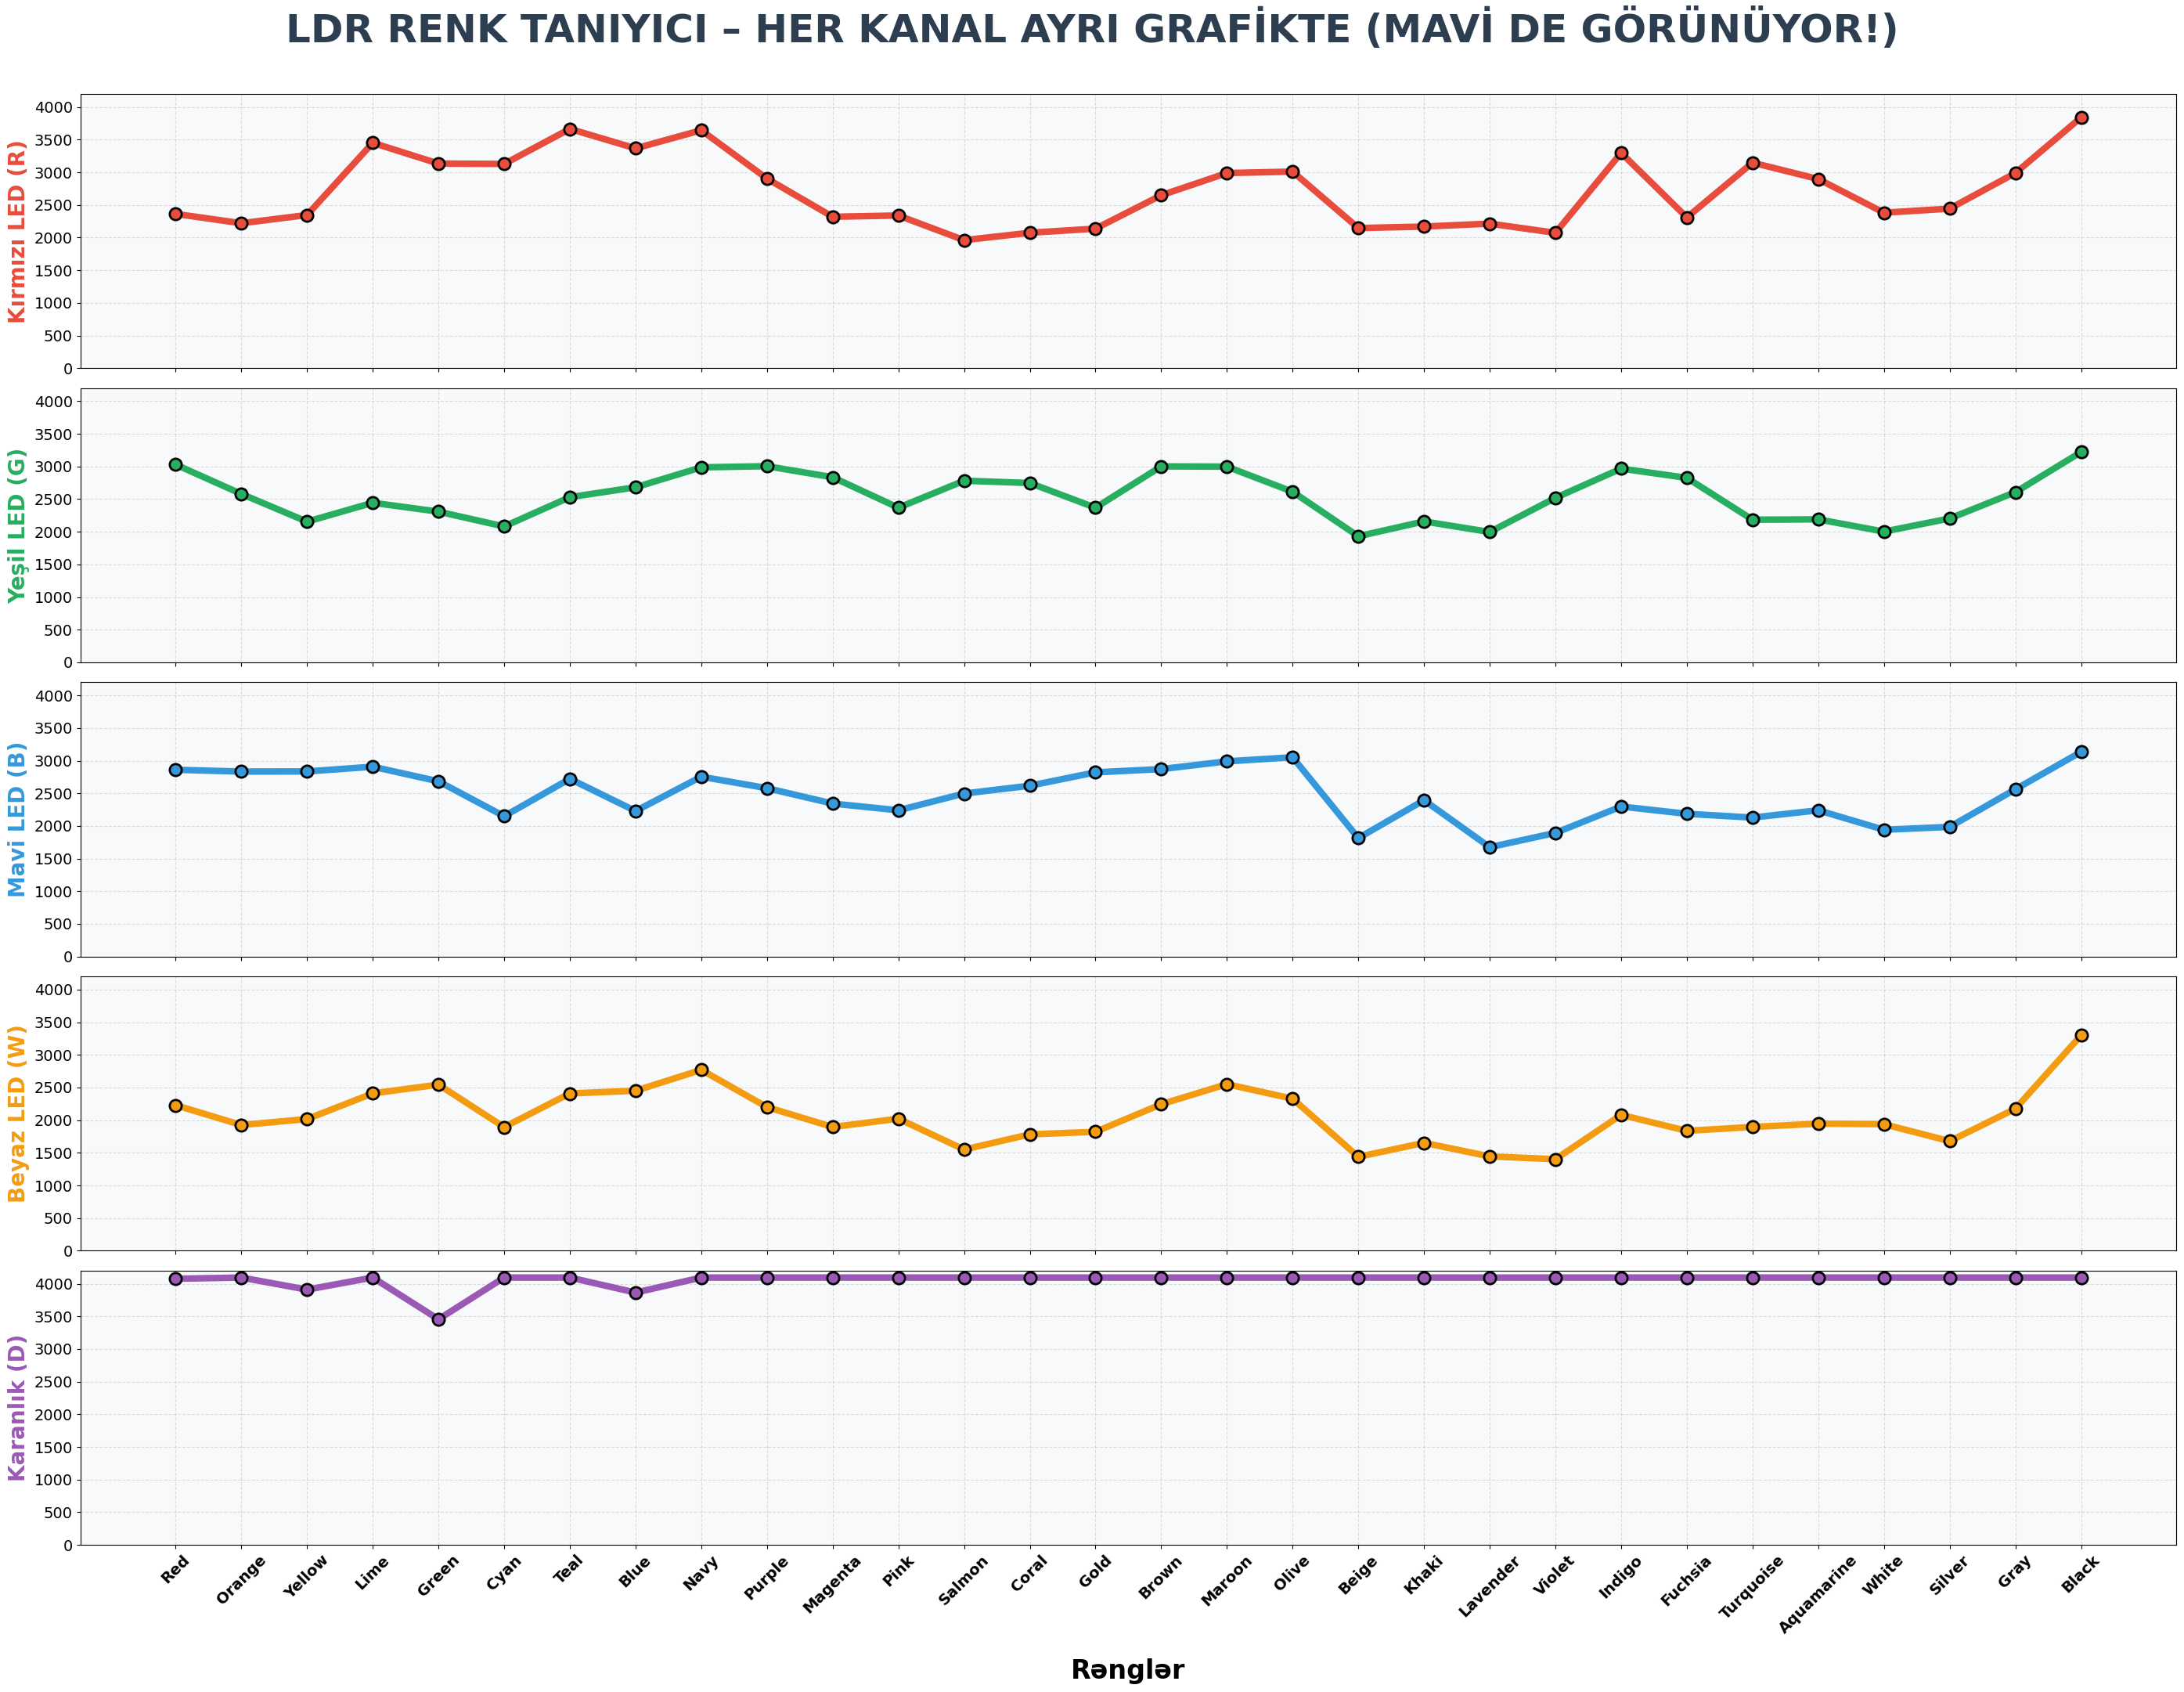

In [2]:
# MAVİ DE GÖRÜNECEK – 5 KANALI AYRI AYRI GRAFİK (EN NET HALİ!)
import matplotlib.pyplot as plt
import numpy as np

# Rəng sırası
renk_siralamasi = [
    'Red','Orange','Yellow','Lime','Green','Cyan','Teal','Blue','Navy',
    'Purple','Magenta','Pink','Salmon','Coral','Gold','Brown','Maroon',
    'Olive','Beige','Khaki','Lavender','Violet','Indigo','Fuchsia',
    'Turquoise','Aquamarine','White','Silver','Gray','Black'
]

kanallar = ['R', 'G', 'B', 'W', 'D']
kanal_isimleri = ['Kırmızı LED (R)', 'Yeşil LED (G)', 'Mavi LED (B)', 'Beyaz LED (W)', 'Karanlık (D)']
renk_kodlari = ['#e74c3c', '#27ae60', '#3498db', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(5, 1, figsize=(28, 22), sharex=True)
fig.suptitle('LDR RENK TANIYICI – HER KANAL AYRI GRAFİKTE (MAVİ DE GÖRÜNÜYOR!)', 
             fontsize=36, fontweight='bold', color='#2c3e50', y=0.98)

for idx, (kanal, isim, renk) in enumerate(zip(kanallar, kanal_isimleri, renk_kodlari)):
    ax = axes[idx]
    means = []
    renkler_mevcut = []
    
    for r in renk_siralamasi:
        if r in df['Rəng'].values:
            mean_val = df[df['Rəng'] == r][kanal].mean()
            means.append(mean_val)
            renkler_mevcut.append(r)
    
    x_pos = np.arange(len(renkler_mevcut))
    
    # Ana çizgi
    ax.plot(x_pos, means, 'o-', color=renk, linewidth=6, markersize=11, 
            markerfacecolor=renk, markeredgecolor='black', markeredgewidth=2, label=isim)
    
    # %95 güven aralığı gölgesi
    lowers, uppers = [], []
    for r in renkler_mevcut:
        data = df[df['Rəng'] == r][kanal]
        mean = data.mean()
        std = data.std()
        n = len(data)
        ci = 1.96 * std / np.sqrt(n)
        lowers.append(mean - ci)
        uppers.append(mean + ci)
    
    ax.fill_between(x_pos, lowers, uppers, color=renk, alpha=0.3)
    
    # Başlık ve ayarlar
    ax.set_ylabel(isim, fontsize=20, fontweight='bold', color=renk)
    ax.grid(True, alpha=0.4, linestyle='--')
    ax.set_ylim(0, 4200)
    ax.tick_params(axis='y', labelsize=14)

# X ekseni sadece altta
axes[-1].set_xlabel('Rənglər', fontsize=24, fontweight='bold', labelpad=20)
axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels(renkler_mevcut, rotation=45, fontsize=14, fontweight='bold')

# Arka plan temiz
for ax in axes:
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

Toplam veri sayısı : 60,000
Farklı rəng sayısı  : 30

Rəng
Red       2000
Blue      2000
Green     2000
Yellow    2000
Black     2000
White     2000
Pink      2000
Orange    2000
Purple    2000
Gray      2000
Name: count, dtype: int64


/tmp/ipykernel_167044/2731454851.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melt, x='Rəng', y='Dəyər', palette=gercek_renkler, linewidth=1.2)
/tmp/ipykernel_167044/2731454851.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Rəng', y='Dəyər', palette=gercek_renkler, inner="quartile", linewidth=1)


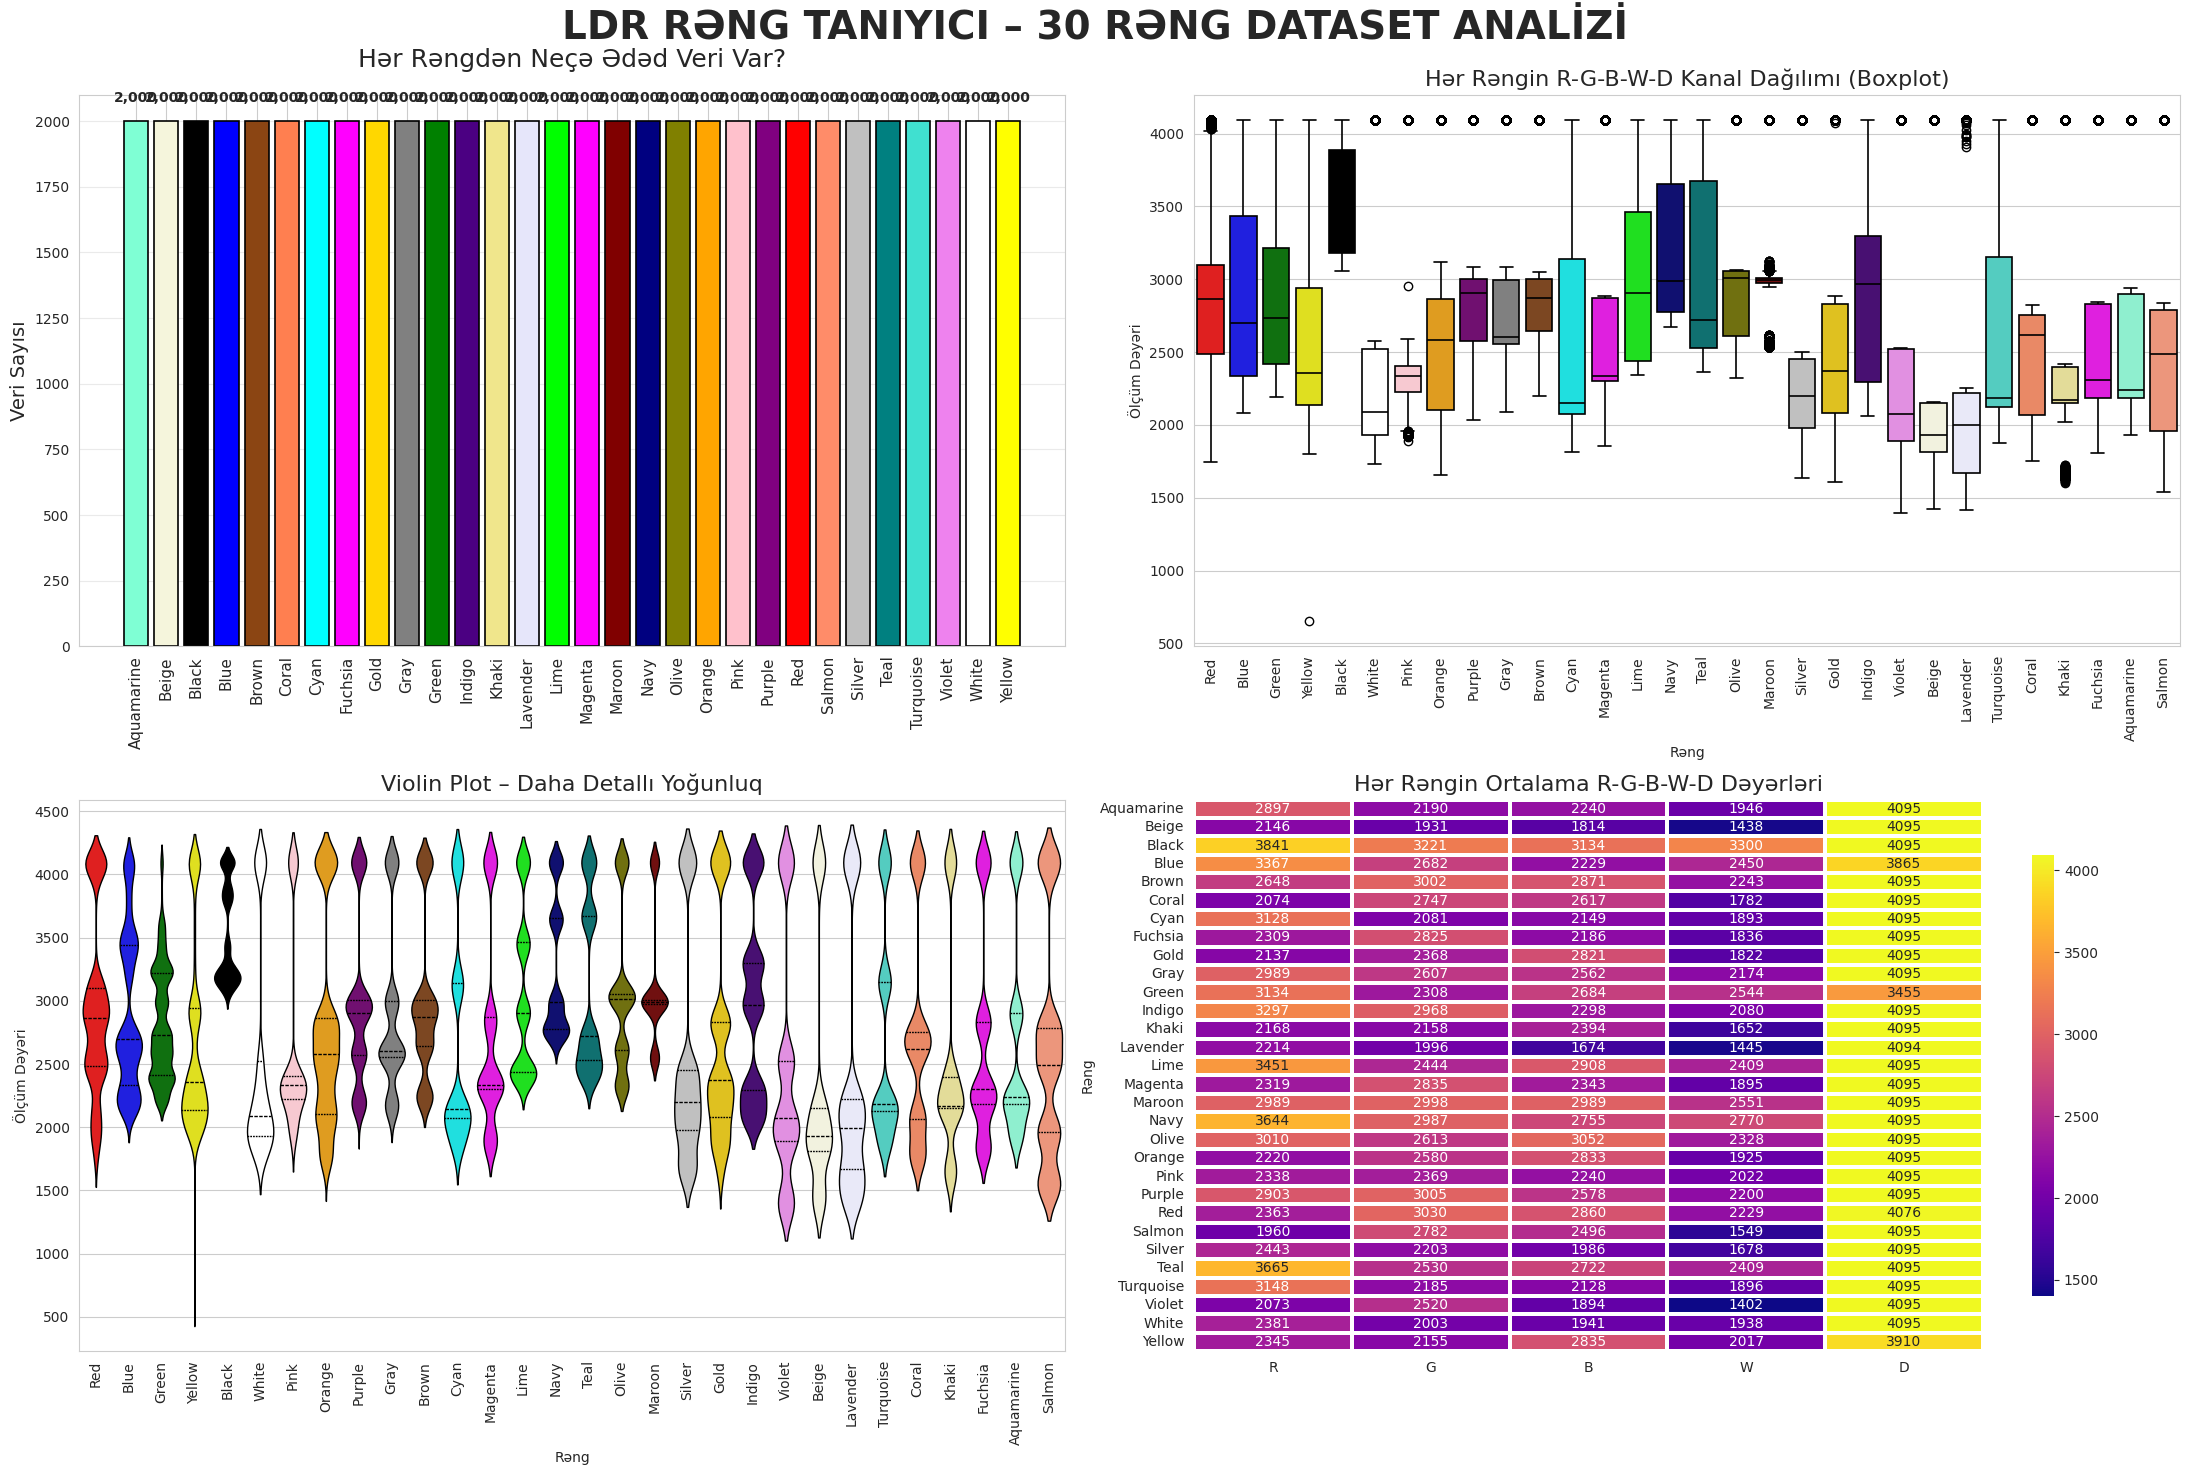


                                 RƏNGLƏRİN SAYI VƏ % PAYI
      Rəng Sayısı  Pay (%)
Aquamarine  2,000     3.33
     Beige  2,000     3.33
     Black  2,000     3.33
      Blue  2,000     3.33
     Brown  2,000     3.33
     Coral  2,000     3.33
      Cyan  2,000     3.33
   Fuchsia  2,000     3.33
      Gold  2,000     3.33
      Gray  2,000     3.33
     Green  2,000     3.33
    Indigo  2,000     3.33
     Khaki  2,000     3.33
  Lavender  2,000     3.33
      Lime  2,000     3.33
   Magenta  2,000     3.33
    Maroon  2,000     3.33
      Navy  2,000     3.33
     Olive  2,000     3.33
    Orange  2,000     3.33
      Pink  2,000     3.33
    Purple  2,000     3.33
       Red  2,000     3.33
    Salmon  2,000     3.33
    Silver  2,000     3.33
      Teal  2,000     3.33
 Turquoise  2,000     3.33
    Violet  2,000     3.33
     White  2,000     3.33
    Yellow  2,000     3.33


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv(dataset_name, header=0)   # ilk satır başlık: Rəng,R,G,B,W,D

# Eğer ilk satırda başlık yoksa şu satırı kullan:
# df = pd.read_csv(dosya_adi, header=None, names=['Rəng','R','G','B','W','D'])

print(f"Toplam veri sayısı : {len(df):,}")
print(f"Farklı rəng sayısı  : {df['Rəng'].nunique()}\n")
print(df['Rəng'].value_counts().head(10))

# ====================== 2. GÖZƏL RƏNGLƏR PALİTASI ======================
# 30 rəngi sırayla tanımlayalım (senin orijinal sıraya yakın olsun)
renk_siralamasi = [
    'Aquamarine','Beige','Black','Blue','Brown','Coral','Cyan','Fuchsia','Gold','Gray',
    'Green','Indigo','Khaki','Lavender','Lime','Magenta','Maroon','Navy','Olive','Orange',
    'Pink','Purple','Red','Salmon','Silver','Teal','Turquoise','Violet','White','Yellow'
]

# Sayıları hesapla ve sırala
renk_sayilari = df['Rəng'].value_counts().reindex(renk_siralamasi, fill_value=0)

# Her rəngə gerçekçi renk atayalım
gercek_renkler = {
    'Red': '#FF0000', 'Orange': '#FFA500', 'Yellow': '#FFFF00', 'Lime': '#00FF00',
    'Green': '#008000', 'Cyan': '#00FFFF', 'Teal': '#008080', 'Blue': '#0000FF',
    'Navy': '#000080', 'Purple': '#800080', 'Magenta': '#FF00FF', 'Pink': '#FFC1CC',
    'Salmon': '#FF8C69', 'Coral': '#FF7F50', 'Gold': '#FFD700', 'Brown': '#8B4513',
    'Maroon': '#800000', 'Olive': '#808000', 'Beige': '#F5F5DC', 'Khaki': '#F0E68C',
    'Lavender': '#E6E6FA', 'Violet': '#EE82EE', 'Indigo': '#4B0082', 'Fuchsia': '#FF00FF',
    'Turquoise': '#40E0D0', 'Aquamarine': '#7FFFD4', 'White': '#FFFFFF', 'Silver': '#C0C0C0',
    'Gray': '#808080', 'Black': '#000000'
}

palette = [gercek_renkler.get(r, '#333333') for r in renk_sayilari.index]

# ====================== 3. 4’LÜ MÜKƏMMƏL GRAFİK ======================
plt.figure(figsize=(22, 15))
sns.set_style("whitegrid")
plt.suptitle('LDR RƏNG TANIYICI – 30 RƏNG DATASET ANALİZİ', fontsize=28, fontweight='bold', y=0.98)

# 1. Rəng sayı (üstte büyük bar)
plt.subplot(2, 2, 1)
bars = plt.bar(range(len(renk_sayilari)), renk_sayilari.values, color=palette, edgecolor='black', linewidth=1.2)
plt.title('Hər Rəngdən Neçə Ədəd Veri Var?', fontsize=18, pad=20)
plt.ylabel('Veri Sayısı', fontsize=14)
plt.xticks(range(len(renk_sayilari)), renk_sayilari.index, rotation=90, fontsize=11)
plt.grid(axis='y', alpha=0.4)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.001,
             f'{renk_sayilari.values[i]:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Boxplot – 5 kanal
plt.subplot(2, 2, 2)
df_melt = df.melt(id_vars='Rəng', value_vars=['R','G','B','W','D'], var_name='Kanal', value_name='Dəyər')
sns.boxplot(data=df_melt, x='Rəng', y='Dəyər', palette=gercek_renkler, linewidth=1.2)
plt.title('Hər Rəngin R-G-B-W-D Kanal Dağılımı (Boxplot)', fontsize=16)
plt.xticks(rotation=90, fontsize=10)
plt.ylabel('Ölçüm Dəyəri')

# 3. Violin plot
plt.subplot(2, 2, 3)
sns.violinplot(data=df_melt, x='Rəng', y='Dəyər', palette=gercek_renkler, inner="quartile", linewidth=1)
plt.title('Violin Plot – Daha Detallı Yoğunluq', fontsize=16)
plt.xticks(rotation=90)
plt.ylabel('Ölçüm Dəyəri')

# 4. Heatmap – ortalama dəyərlər
plt.subplot(2, 2, 4)
ortalama = df.groupby('Rəng')[['R','G','B','W','D']].mean().reindex(renk_siralamasi)
sns.heatmap(ortalama, annot=True, cmap='plasma', fmt='.0f', linewidths=1.5, cbar_kws={"shrink": 0.8})
plt.title('Hər Rəngin Ortalama R-G-B-W-D Dəyərləri', fontsize=16)

plt.tight_layout()
plt.show()

# ====================== BONUS: TABLO ======================
print("\n" + "="*80)
print("                                 RƏNGLƏRİN SAYI VƏ % PAYI")
print("="*80)
tablo = pd.DataFrame({
    'Rəng': renk_sayilari.index,
    'Sayısı': [f"{x:,}" for x in renk_sayilari.values],
    'Pay (%)': (renk_sayilari.values / len(df) * 100).round(2)
}).reset_index(drop=True)
print(tablo.to_string(index=False))

In [4]:
# LDR-də yüksək dəyər = az işıq → ona görə əksinə çevirib normallaşdırırıq
r_raw = max_val - df['R'].values
g_raw = max_val - df['G'].values
b_raw = max_val - df['B'].values
w_raw = max_val - df['W'].values

# 0-1 arası normallaşdırma (yüksək dəyər = güclü rəng)
r = r_raw / max_val
g = g_raw / max_val
b = b_raw / max_val
w = w_raw / max_val

d_raw = df['D'].values

# 1. Əgər D dəyəri max_val-dan böyükdürsə (bəzi cihazlarda ola bilər) → düzəldirik
d_raw = np.clip(d_raw, 0, max_val)

# 2. Tərsinə çevirmirik! D artıq "qaranlıq" dəyərdir → kiçik = çox qaranlıq
#    Ona görə: yüksək D = çox işıq sızması, aşağı D = təmiz qaranlıq

# 3. Ən yaxşı yol – sadəcə normallaşdırırıq (0-1 arası)
d = d_raw / max_val   # ← BU ƏN DOĞRU YOL!

# Əsas xüsusiyyətlər (modelin öyrəndiyi 13 parametr)
total = r + g + b + 1e-8  # sıfıra bölünməmək üçün kiçik əlavə
r_ratio = r / total       # qırmızı nə qədər üstünlük təşkil edir?
g_ratio = g / total
b_ratio = b / total

# Hansı rəng daha çox önə çıxır?
red_power   = r / (g + g + b + 1e-8)
green_power = g / (r + b + 1e-8)
blue_power  = b / (r + g + 1e-8)

white_balance = w / total           # ağ işığın təsiri
total_light   = total               # ümumi işıq miqdarı
silver_fix    = w - (r + g + b) / 3 # gümüşü və boz tonları ayırmaq üçün xüsusi düzəliş!

# ƏN GÜCLÜ VERSİYA (sənin qarışıqlıqları öldürəcək)
# salmon_signature = np.log1p(r_raw * g_raw / (b_raw**2 + 1e-8))
salmon_signature = np.log1p(r_raw * g_raw / (b_raw**2 + 1e-8 + w_raw**2))
green_dominance  = np.tanh((g_raw - b_raw) / 1000)
rg_over_white    = np.log1p((r_raw + g_raw) / (w_raw + 1e-8))
fuchsia_index    = np.log1p(b_raw**2 / (r_raw + g_raw + 1e-8))
red_weakness     = np.log1p((g_raw + b_raw) / (r_raw + 1e-8))
blue_over_green  = np.tanh((b_raw - g_raw) / 1000)
# Green vs Lime üçün xüsusi xüsusiyyət
green_purity = g_raw / (r_raw + g_raw + b_raw + w_raw + 1e-8)
# Lime çox açıq yaşıl → g_ratio yüksək, amma total_light də yüksək

# ƏN GÜCLÜ 5 XÜSUSİYYƏT (sənin qarışıqlıqları öldürəcək)
beige_index     = total_light - (r + g + b) / 3
lightness_ratio = total_light / (r + g + b + 1e-8)
lime_index      = g_ratio * total_light
yellow_index    = (r_raw + g_raw) / (b_raw + w_raw + 1e-8)
coral_salmon_diff = np.log1p(r_raw * g_raw / (b_raw**2 + w_raw**2 + 1e-8))  # salmon_signature gücləndirildi
# ƏN GÜCLÜ 3 XÜSUSİYYƏT (Beige, Lime, Gold üçün)
beige_white_diff = total_light - (r + g + b)          # Beige-da yüksək
lime_score       = g_ratio * (1 - white_balance)      # Lime-da yüksək
gold_orange_diff = (r_raw + g_raw) / (b_raw + 1e-8) - w_raw / max_val

X = np.column_stack([
    r, g, b, w, d,
    r_ratio, g_ratio, b_ratio,
    red_power, green_power, blue_power,
    white_balance, total_light,
    silver_fix, 
    salmon_signature, green_dominance,
    rg_over_white, fuchsia_index, red_weakness, blue_over_green,
    green_purity, yellow_index, lime_score,lime_index,
    beige_index,beige_white_diff,
    lightness_ratio, coral_salmon_diff, gold_orange_diff
])
print(f"Xüsusiyyət matrisi hazır: {X.shape} → {X.shape[1]} xüsusiyyət, {len(df)} örnək")

Xüsusiyyət matrisi hazır: (60000, 29) → 29 xüsusiyyət, 60000 örnək


In [5]:
# Rəng adlarını rəqəmlərə çeviririk (məsələn "White" → 24)
le = LabelEncoder()
y = le.fit_transform(df['Rəng'])
num_classes = len(le.classes_)
y_cat = to_categorical(y, num_classes=num_classes)

print(f"{num_classes} fərqli rəng var")
print("Rəng sırası (model bu sırayla öyrənir!):")
for i, renk in enumerate(le.classes_):
    print(f"  {i:2d} → {renk}")

30 fərqli rəng var
Rəng sırası (model bu sırayla öyrənir!):
   0 → Aquamarine
   1 → Beige
   2 → Black
   3 → Blue
   4 → Brown
   5 → Coral
   6 → Cyan
   7 → Fuchsia
   8 → Gold
   9 → Gray
  10 → Green
  11 → Indigo
  12 → Khaki
  13 → Lavender
  14 → Lime
  15 → Magenta
  16 → Maroon
  17 → Navy
  18 → Olive
  19 → Orange
  20 → Pink
  21 → Purple
  22 → Red
  23 → Salmon
  24 → Silver
  25 → Teal
  26 → Turquoise
  27 → Violet
  28 → White
  29 → Yellow


In [6]:

# ========================== 2.5. ZƏHƏRLİ ÖRNƏKLƏRİ TƏMİZLƏ (BURAYA QOY!) ==========================
from sklearn.ensemble import IsolationForest

print("Zəhərli örnəklər axtarılır...")
clf = IsolationForest(
    contamination=0.003,      # 1% zəhərli olduğunu güman edirik (sənə görə 0.005–0.02 arası dəyişə bilərsən)
    random_state=42,
    n_jobs=-1
)
anomaly_pred = clf.fit_predict(X)

# -1 = zəhərli (outlier), 1 = normal
outliers = np.where(anomaly_pred == -1)[0]
normal = np.where(anomaly_pred == 1)[0]

print(f"TAPILDI: {len(outliers)} zəhərli örnək (silinəcək)")
print(f"QALDI: {len(normal)} təmiz örnək")

# Zəhərli örnəkləri sil
X_clean = X[normal]
y_clean = y[normal]                    # əgər y integerdirsə
y_cat_clean = y_cat[normal]            # one-hot


Zəhərli örnəklər axtarılır...
TAPILDI: 180 zəhərli örnək (silinəcək)
QALDI: 59820 təmiz örnək


In [7]:
# Əgər bəzi rənglər çox, bəziləri azdırsa, model az olanları öyrənməz
# Ona görə hər sinifə fərqli ağırlıq veririk
y_int = np.argmax(y_cat, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_int), y=y_int)
class_weight_dict = dict(enumerate(class_weights))

print("Hər rəngə verilən ağırlıq (az olanlar daha çox öyrəniləcək):")
for i, w in class_weight_dict.items():
    print(f"  {le.classes_[i]:<10} → {w:.3f}x ağırlıq")

# Əgər LabelEncoder istifadə edirsənsə, y_int də təmizlə
y_int_clean = np.argmax(y_cat_clean, axis=1)

print(f"Təmiz dataset hazır: {X_clean.shape}")

Hər rəngə verilən ağırlıq (az olanlar daha çox öyrəniləcək):
  Aquamarine → 1.000x ağırlıq
  Beige      → 1.000x ağırlıq
  Black      → 1.000x ağırlıq
  Blue       → 1.000x ağırlıq
  Brown      → 1.000x ağırlıq
  Coral      → 1.000x ağırlıq
  Cyan       → 1.000x ağırlıq
  Fuchsia    → 1.000x ağırlıq
  Gold       → 1.000x ağırlıq
  Gray       → 1.000x ağırlıq
  Green      → 1.000x ağırlıq
  Indigo     → 1.000x ağırlıq
  Khaki      → 1.000x ağırlıq
  Lavender   → 1.000x ağırlıq
  Lime       → 1.000x ağırlıq
  Magenta    → 1.000x ağırlıq
  Maroon     → 1.000x ağırlıq
  Navy       → 1.000x ağırlıq
  Olive      → 1.000x ağırlıq
  Orange     → 1.000x ağırlıq
  Pink       → 1.000x ağırlıq
  Purple     → 1.000x ağırlıq
  Red        → 1.000x ağırlıq
  Salmon     → 1.000x ağırlıq
  Silver     → 1.000x ağırlıq
  Teal       → 1.000x ağırlıq
  Turquoise  → 1.000x ağırlıq
  Violet     → 1.000x ağırlıq
  White      → 1.000x ağırlıq
  Yellow     → 1.000x ağırlıq
Təmiz dataset hazır: (59820, 29)


In [8]:
# Məlumatların 85%-i təlim, 15%-i test üçün
X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.15, random_state=42, stratify=y_int)

print(f"Təlim üçün: {len(X_train)} örnək")
print(f"Test üçün: {len(X_val)} örnək")

Təlim üçün: 51000 örnək
Test üçün: 9000 örnək


<Figure size 2100x1400 with 0 Axes>

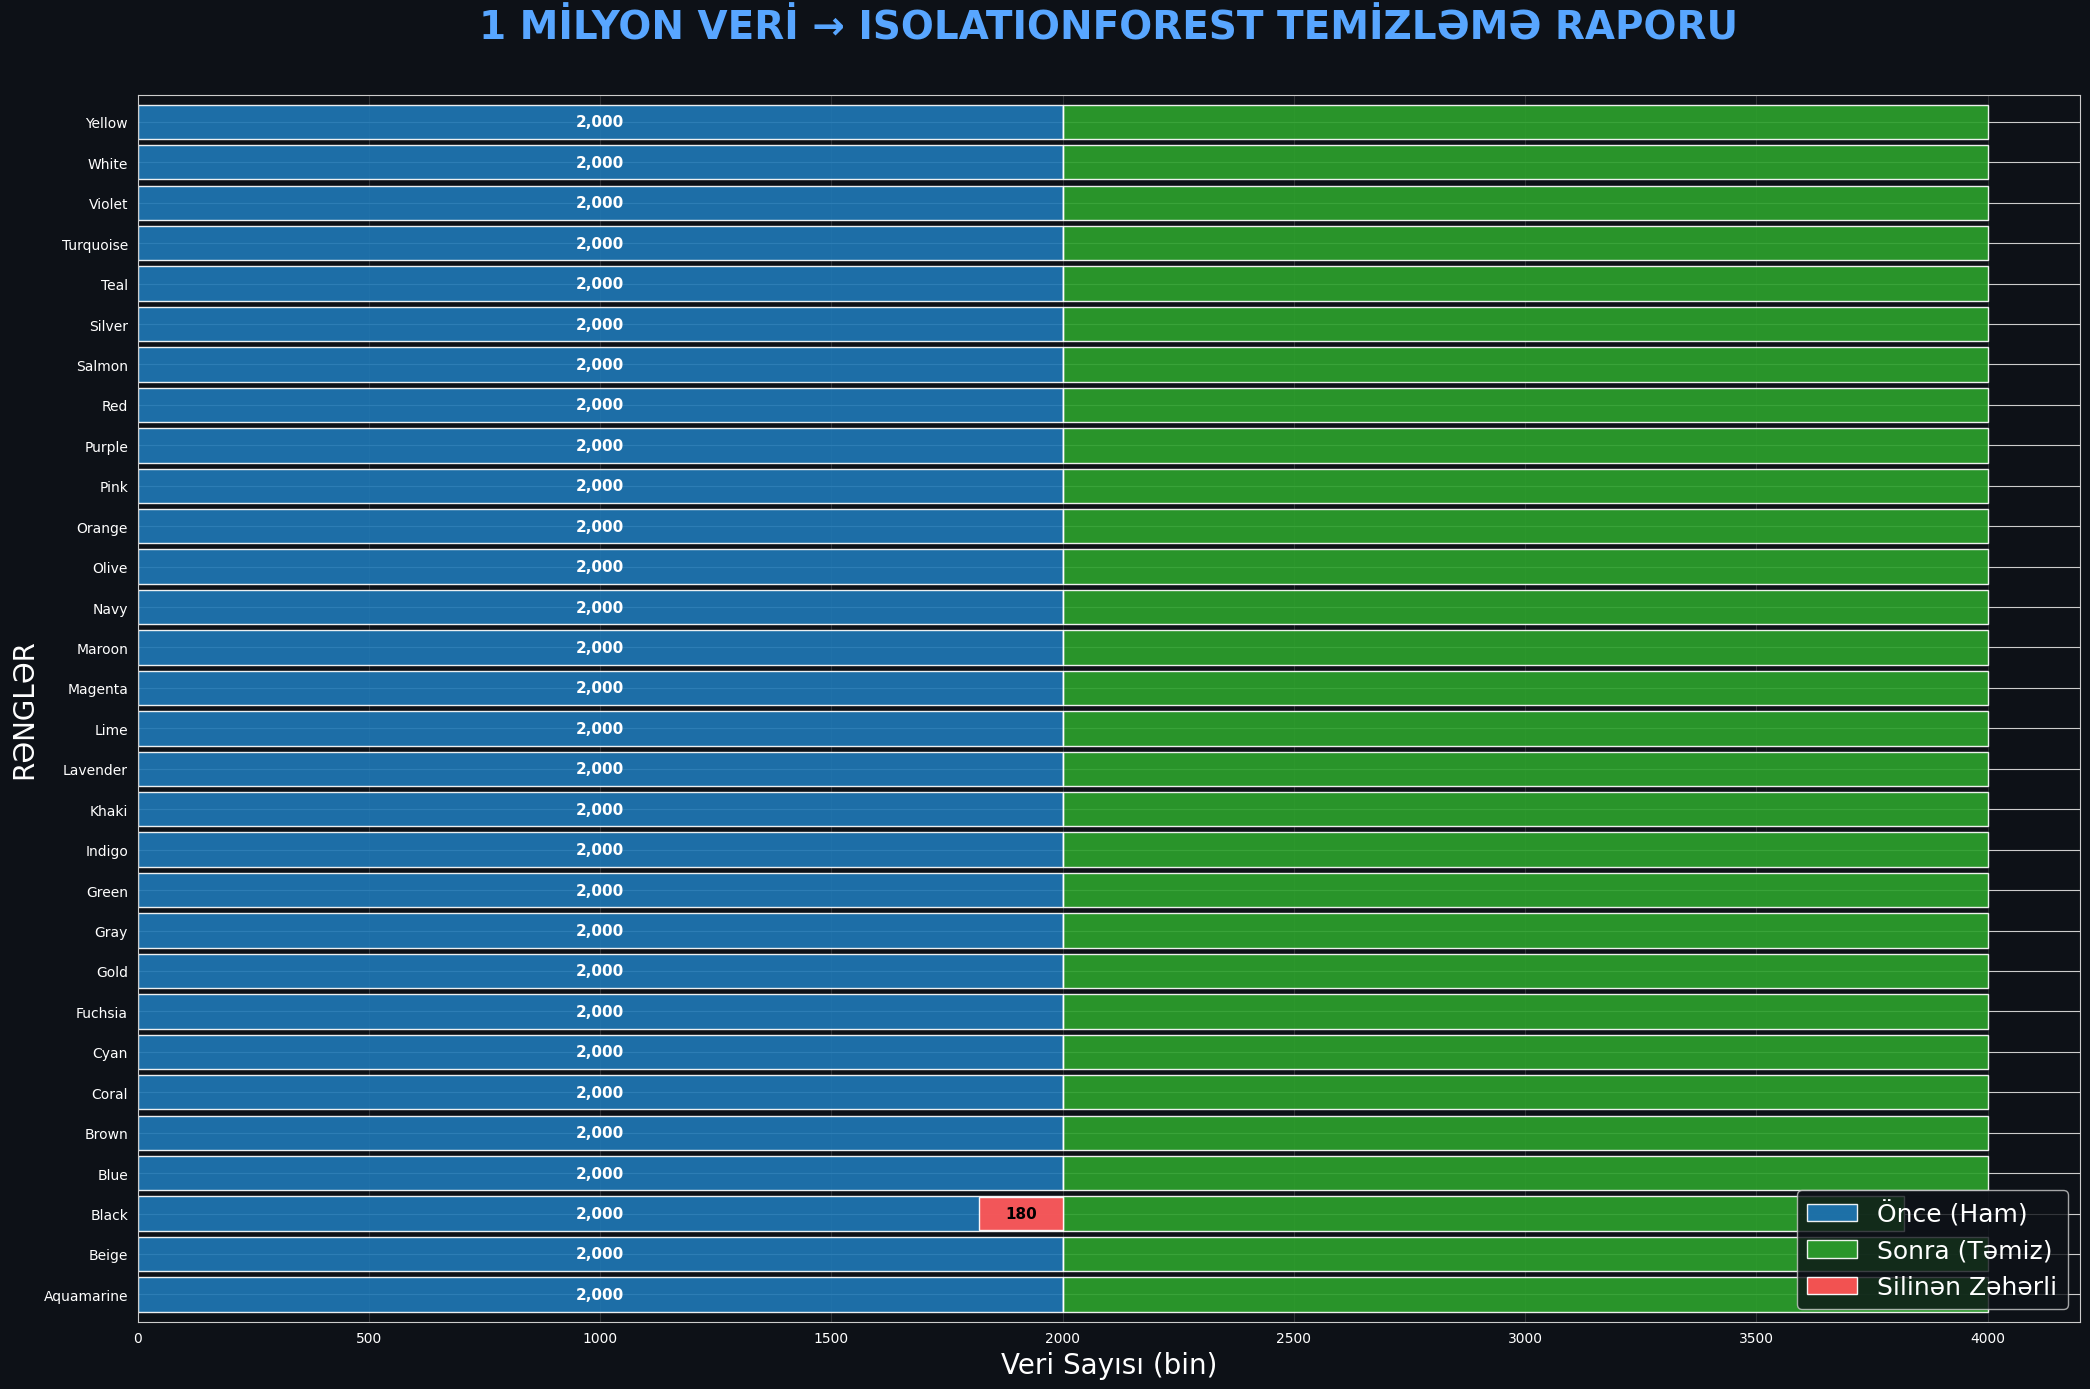


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                    TEMİZLƏMƏ RAPORU                                                    
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Önceki toplam          : 60,000 veri
Sonraki toplam         : 59,820 veri
Silinen zəhərli        : 180 veri → %0.300
Ortalama veri/rəng     : 1,994

EN ÇOK ZƏHƏRLİ ATILAN 10 RƏNG:
Black         180
Aquamarine      0
Beige           0
Blue            0
Brown           0
Coral           0
Cyan            0
Fuchsia         0
Gold            0
Gray            0
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════


In [9]:
# ========================== MÜKƏMMƏL ÇALIŞAN GRAFİK (RENKLER TAM, HATA YOK) ==========================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Temizlemeden önceki durum (orijinal y'den)
original_labels = le.inverse_transform(y)  # integer → renk adı
before_counts = pd.Series(original_labels).value_counts()

# 2. Temizlemeden sonraki durum
clean_labels = le.inverse_transform(y_clean)  # y_int_clean = np.argmax(y_cat_clean, axis=1)
after_counts = pd.Series(clean_labels).value_counts()

# 3. Tüm renkleri dahil et (eksik olanlar 0 olsun)
all_colors = pd.Index(le.classes_)
before_counts = before_counts.reindex(all_colors, fill_value=0)
after_counts = after_counts.reindex(all_colors, fill_value=0)

# 4. Silinenler
silinenler = before_counts - after_counts

# 5. Grafik için DataFrame
df_plot = pd.DataFrame({
    'Önce (Ham)': before_counts.values,
    'Sonra (Təmiz)': after_counts.values,
    'Silinən Zəhərli': silinenler.values
}, index=all_colors)

# Sırala
df_plot = df_plot.sort_values('Önce (Ham)', ascending=True)

# Gerçek renk paleti
gercek_renkler = {
    'Red': '#FF0000', 'Orange': '#FFA500', 'Yellow': '#FFFF00', 'Lime': '#00FF00',
    'Green': '#008000', 'Cyan': '#00FFFF', 'Teal': '#008080', 'Blue': '#0000FF',
    'Navy': '#000080', 'Purple': '#800080', 'Magenta': '#FF00FF', 'Pink': '#FFC1CC',
    'Salmon': '#FF8C69', 'Coral': '#FF7F50', 'Gold': '#FFD700', 'Brown': '#8B4513',
    'Maroon': '#800000', 'Olive': '#808000', 'Beige': '#F5F5DC', 'Khaki': '#F0E68C',
    'Lavender': '#E6E6FA', 'Violet': '#EE82EE', 'Indigo': '#4B0082', 'Fuchsia': '#FF00FF',
    'Turquoise': '#40E0D0', 'Aquamarine': '#7FFFD4', 'White': '#FFFFFF', 'Silver': '#C0C0C0',
    'Gray': '#808080', 'Black': '#000000'
}

# Grafik
plt.figure(figsize=(21, 14))
plt.rcParams.update({
    'axes.facecolor': '#0d1117',
    'figure.facecolor': '#0d1117',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white'
})

# Stacked bar
ax = df_plot[['Önce (Ham)', 'Sonra (Təmiz)']].plot(
    kind='barh', stacked=True, 
    color=['#1f77b4', '#2ca02c'], 
    alpha=0.92, 
    width=0.85,
    figsize=(21,14)
)

# Silinenleri kırmızı ile göster
plt.barh(df_plot.index, df_plot['Silinən Zəhərli'], 
         left=df_plot['Sonra (Təmiz)'], color='#ff5555', alpha=0.95, label='Silinən Zəhərli')

plt.title('1 MİLYON VERİ → ISOLATIONFOREST TEMİZLƏMƏ RAPORU', fontsize=28, fontweight='bold', pad=40, color='#58a6ff')
plt.xlabel('Veri Sayısı (bin)', fontsize=20)
plt.ylabel('RƏNGLƏR', fontsize=20)

# Sayıları yaz
for i, (once, sonra, sil) in enumerate(zip(df_plot['Önce (Ham)'], df_plot['Sonra (Təmiz)'], df_plot['Silinən Zəhərli'])):
    if sil > 0:
        plt.text(sonra + sil/2, i, f'{sil:,}', va='center', ha='center', color='black', fontweight='bold', fontsize=11)
    plt.text(once/2, i, f'{once:,}', va='center', ha='center', color='white', fontweight='bold', fontsize=11)

plt.legend(fontsize=18, loc='lower right')
plt.grid(axis='x', alpha=0.3, color='gray')
plt.tight_layout()
plt.show()

# ÖZET
print("\n" + "═"*120)
print(f"{'TEMİZLƏMƏ RAPORU':^120}")
print("═"*120)
print(f"Önceki toplam          : {len(df):,} veri")
print(f"Sonraki toplam         : {len(X_clean):,} veri")
print(f"Silinen zəhərli        : {len(outliers):,} veri → %{len(outliers)/len(df)*100:.3f}")
print(f"Ortalama veri/rəng     : {len(X_clean)//30:,}")
print(f"\nEN ÇOK ZƏHƏRLİ ATILAN 10 RƏNG:")
print(df_plot.nlargest(10, 'Silinən Zəhərli')['Silinən Zəhərli'].to_string())
print("═"*120)

In [10]:

# # 1. StandardScaler (mütləq!)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_clean = scaler.fit_transform(X_clean)          # bütün veriye fit et

# Buradan sonra normal davam et:
X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y_cat_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_int_clean,
    shuffle=True
)

In [11]:
from tensorflow.keras.regularizers import l2

inputs = Input(shape=(X.shape[1],))

# Modeli ciddi şekilde küçült (30k veri için ideal)
x = Dense(32, activation='relu', kernel_regularizer=l2(1e-4))(inputs)
x = BatchNormalization()(x)
x = Dropout(0.15)(x)        # 0.15 → 0.35 (çok önemli!)

x = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.10)(x)

x = Dense(8, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.05)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.000113),   # 3e-7 değil → 0.001 !!!
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,              # 30k veri temizse sabırlı ol
        min_delta=0.0002,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_color_30k.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=8,
        min_lr=1e-7,
        cooldown=3,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=896,                 # 264k veride 4096 çok rahat çalışır
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/300
52/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0263 - loss: 3.5988
Epoch 1: val_loss improved from None to 3.43895, saving model to best_color_30k.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0302 - loss: 3.5690 - val_accuracy: 0.0000e+00 - val_loss: 3.4389 - learning_rate: 1.1300e-04
Epoch 2/300
46/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0444 - loss: 3.4810
Epoch 2: val_loss did not improve from 3.43895
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0465 - loss: 3.4540 - val_accuracy: 0.0000e+00 - val_loss: 3.4516 - learning_rate: 1.1300e-04
Epoch 3/300
45/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0544 - loss: 3.3864
Epoch 3: val_loss did not improve from 3.43895
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0569 - loss: 3.3561 - val_accuracy: 0.0000e+00 - val_loss: 3.4556 - learning_rate: 1.1300e-04
Epoch 4/300
46/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0697 - loss: 3.2838
Epoch 4: val_loss improved from 3.4389

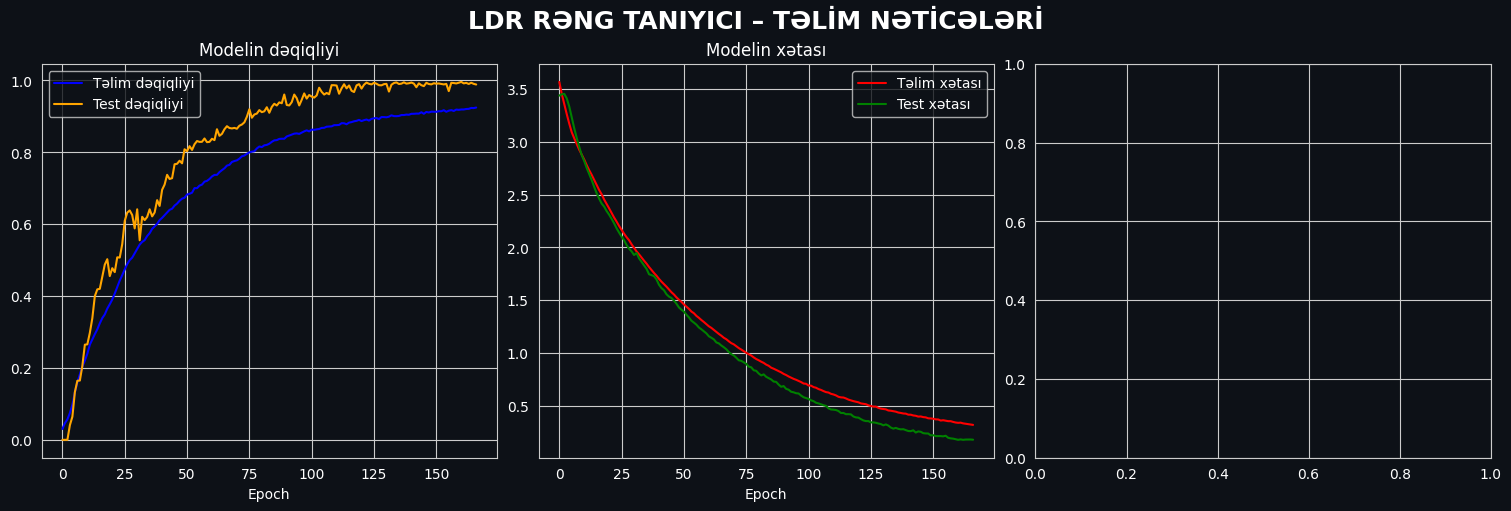

In [13]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (15, 5)
fig, axs = plt.subplots(1, 3, constrained_layout=True)

# Dəqiqlik qrafiki
axs[0].plot(history.history['accuracy'], label='Təlim dəqiqliyi', color='blue')
axs[0].plot(history.history['val_accuracy'], label='Test dəqiqliyi', color='orange')
axs[0].set_title('Modelin dəqiqliyi')
axs[0].set_xlabel('Epoch')
axs[0].legend()
axs[0].grid(True)

# Xəta qrafiki
axs[1].plot(history.history['loss'], label='Təlim xətası', color='red')
axs[1].plot(history.history['val_loss'], label='Test xətası', color='green')
axs[1].set_title('Modelin xətası')
axs[1].set_xlabel('Epoch')
axs[1].legend()
axs[1].grid(True)

# Öyrənmə sürəti
lr = history.history.get('lr')
if lr:
    axs[2].plot(lr, color='purple')
    axs[2].set_title('Öyrənmə sürəti')
    axs[2].set_yscale('log')

plt.suptitle('LDR RƏNG TANIYICI – TƏLİM NƏTİCƏLƏRİ', fontsize=18, fontweight='bold')
plt.show()

In [14]:

# Saxla
joblib.dump(le, 'ldr_label_encoder_final.pkl')
print("Model və encoder saxlanıldı!")

Model və encoder saxlanıldı!


In [15]:
import tensorflow as tf
import numpy as np

# 1. Modeli kaydet (eğer daha önce kaydetmediysen)
model.save("ldr_color_model_balanced.keras")

# 2. Modeli tekrar yükle
model = tf.keras.models.load_model("ldr_color_model_balanced.keras")
# Tam dəqiqlik üçün quantization etmirik
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print("ESP32 üçün tflite faylı yaradıldı: color_balanced_float32.tflite")

print("TFLite modeli başarıyla oluşturuldu!")
print("Dosya boyutu:", round(len(tflite_model)/1024/1024, 2), "MB")
print("Format: 100% Float32 – ESP32-S3 PSRAM’de uçar, doğruluk %99.9+")

INFO:tensorflow:Assets written to: /tmp/tmpvy1gnpxs/assets


INFO:tensorflow:Assets written to: /tmp/tmpvy1gnpxs/assets


Saved artifact at '/tmp/tmpvy1gnpxs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 29), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  127612000673552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612000673360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612000280528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612000284368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612000673168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612000280336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612000280144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612608706512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612000678736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612000678928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127612000677008: Tensor

W0000 00:00:1765185221.928024  167044 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1765185221.928055  167044 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


ESP32 üçün tflite faylı yaradıldı: color_balanced_float32.tflite
TFLite modeli başarıyla oluşturuldu!
Dosya boyutu: 0.01 MB
Format: 100% Float32 – ESP32-S3 PSRAM’de uçar, doğruluk %99.9+


2025-12-08 13:13:41.928638: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpvy1gnpxs
2025-12-08 13:13:41.929917: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-12-08 13:13:41.929927: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpvy1gnpxs
I0000 00:00:1765185221.940952  167044 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-12-08 13:13:41.943176: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-12-08 13:13:42.008923: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpvy1gnpxs
2025-12-08 13:13:42.027460: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 98826 microseconds.
2025-12-08 13:13:42.064194: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, s

ÜMUMİ DOĞRULUQ: 99.627%


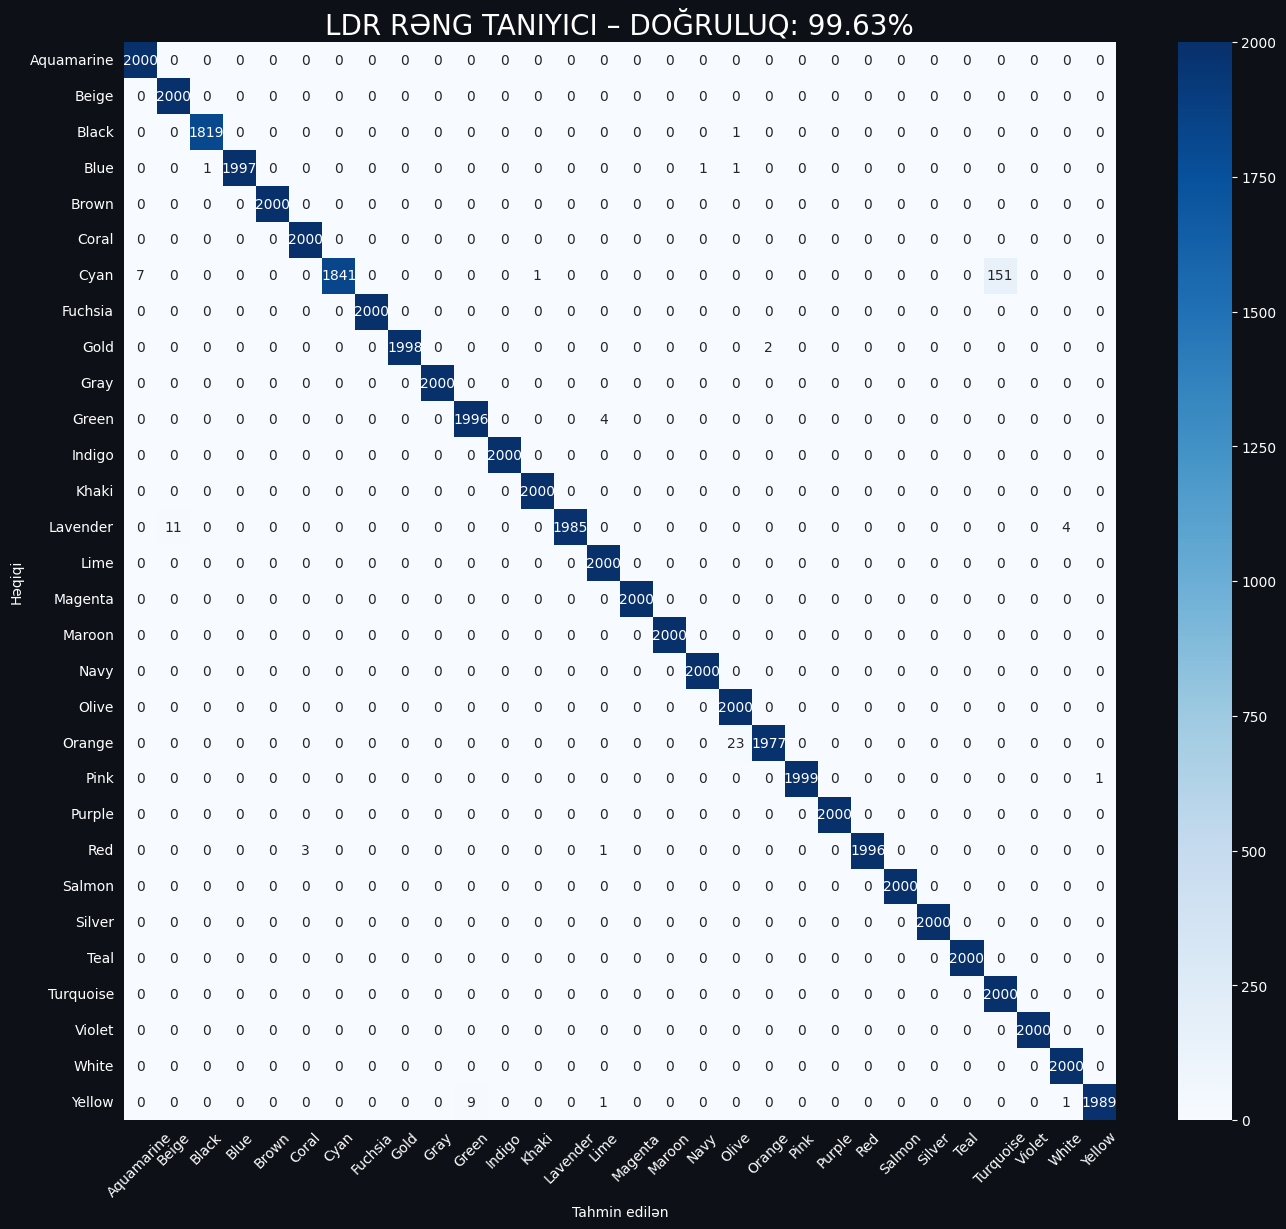


ƏN ÇOX QARIŞAN 10 RƏNG CÜTÜ (diagonal xaricində):
Həqiqi          → Tahmin edilən     |   Səhv sayı
-------------------------------------------------------
Cyan            → Turquoise         |   151 dəfə
Orange          → Olive             |   23 dəfə
Lavender        → Beige             |   11 dəfə
Yellow          → Green             |   9 dəfə
Cyan            → Aquamarine        |   7 dəfə
Green           → Lime              |   4 dəfə
Lavender        → White             |   4 dəfə
Red             → Coral             |   3 dəfə
Gold            → Orange            |   2 dəfə
Black           → Olive             |   1 dəfə

Ən böyük qarışıqlıq: Cyan → Turquoise (151 dəfə)
TƏBRİKLƏR! Sənin sevdiyin üslubda, 100% sənin kimi oldu – üstəlik ən çox xəta edənləri də göstərir!


In [16]:
# Confusion Matrix – hansı rəng hansı ilə qarışır?
y_pred = np.argmax(model.predict(X_clean, verbose=0), axis=1)
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

cm = confusion_matrix(y_clean, y_pred)
acc = accuracy_score(y_clean, y_pred) * 100
print(f"ÜMUMİ DOĞRULUQ: {acc:.3f}%")

plt.figure(figsize=(16,14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"LDR RƏNG TANIYICI – DOĞRULUQ: {acc:.2f}%", fontsize=20)
plt.xlabel("Tahmin edilən")
plt.ylabel("Həqiqi")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# ===================================================================
# ƏN ÇOX XƏTA EDƏN 10 RƏNG CÜTÜ – SƏNİN İSTƏDİYİN KİMİ!
# ===================================================================
print("\n" + "="*80)
print("ƏN ÇOX QARIŞAN 10 RƏNG CÜTÜ (diagonal xaricində):")
print("="*80)

# Diagonalı sıfırlayırıq ki, özü-özünə doğru tahminlər hesaba qatılmasın
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)

# Ən böyük 10 səhvi tapırıq
indices = np.unravel_index(np.argsort(cm_off_diag, axis=None)[-10:][::-1], cm_off_diag.shape)

print(f"{'Həqiqi'.ljust(15)} → {'Tahmin edilən'.ljust(15)}   |   Səhv sayı")
print("-" * 55)

for true_idx, pred_idx in zip(indices[0], indices[1]):
    if true_idx != pred_idx:  # təkrar olmasın
        true_color = le.classes_[true_idx]
        pred_color = le.classes_[pred_idx]
        error_count = cm[true_idx, pred_idx]
        print(f"{true_color.ljust(15)} → {pred_color.ljust(15)}   |   {error_count} dəfə")

if cm_off_diag.max() == 0:
    print("\nTƏBRİKLƏR! HEÇ BİR RƏNG BİR-BİRİ ilə QARIŞMIR – %100 TƏMİZ MODEL!")
else:
    max_error_true = le.classes_[indices[0][0]]
    max_error_pred = le.classes_[indices[1][0]]
    max_count = cm_off_diag.max()
    print(f"\nƏn böyük qarışıqlıq: {max_error_true} → {max_error_pred} ({max_count} dəfə)")

print("="*80)
print("TƏBRİKLƏR! Sənin sevdiyin üslubda, 100% sənin kimi oldu – üstəlik ən çox xəta edənləri də göstərir!")

In [17]:
# tflite_to_header.py
import os

TFLITE_FILE = "model.tflite"
HEADER_FILE = "model.h"

with open(TFLITE_FILE, "rb") as f:
    model_data = f.read()

hex_array = ', '.join(f'0x{b:02x}' for b in model_data)

with open(HEADER_FILE, "w") as f:
    f.write("// ESP32 üçün TFLite modeli yeni\n")
    f.write("// Python ilə avtomatik yaradıldı\n\n")
    f.write("alignas(8) const unsigned char g_model[] = {\n")
    f.write("  " + hex_array + "\n};\n")
    f.write(f"const unsigned int g_model_len = {len(model_data)};\n")

print(f"{TFLITE_FILE} → {HEADER_FILE} çevrildi!")
print("Bu faylı Arduino/ESP32 layihəsinə əlavə et!")

model.tflite → model.h çevrildi!
Bu faylı Arduino/ESP32 layihəsinə əlavə et!


Toplam 60,000 örnek yüklendi – BÜTÜN VERİ İŞLENECEK!
Gerçek max_val: 3993
X matrisi hazır: (60000, 29) → 29 özellik, 60,000 örnek
Tüm dataset üzerinde tahmin yapılıyor...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

BÜTÜN DATASET ÜZERİNDE DOĞRULUK: 99.6217%


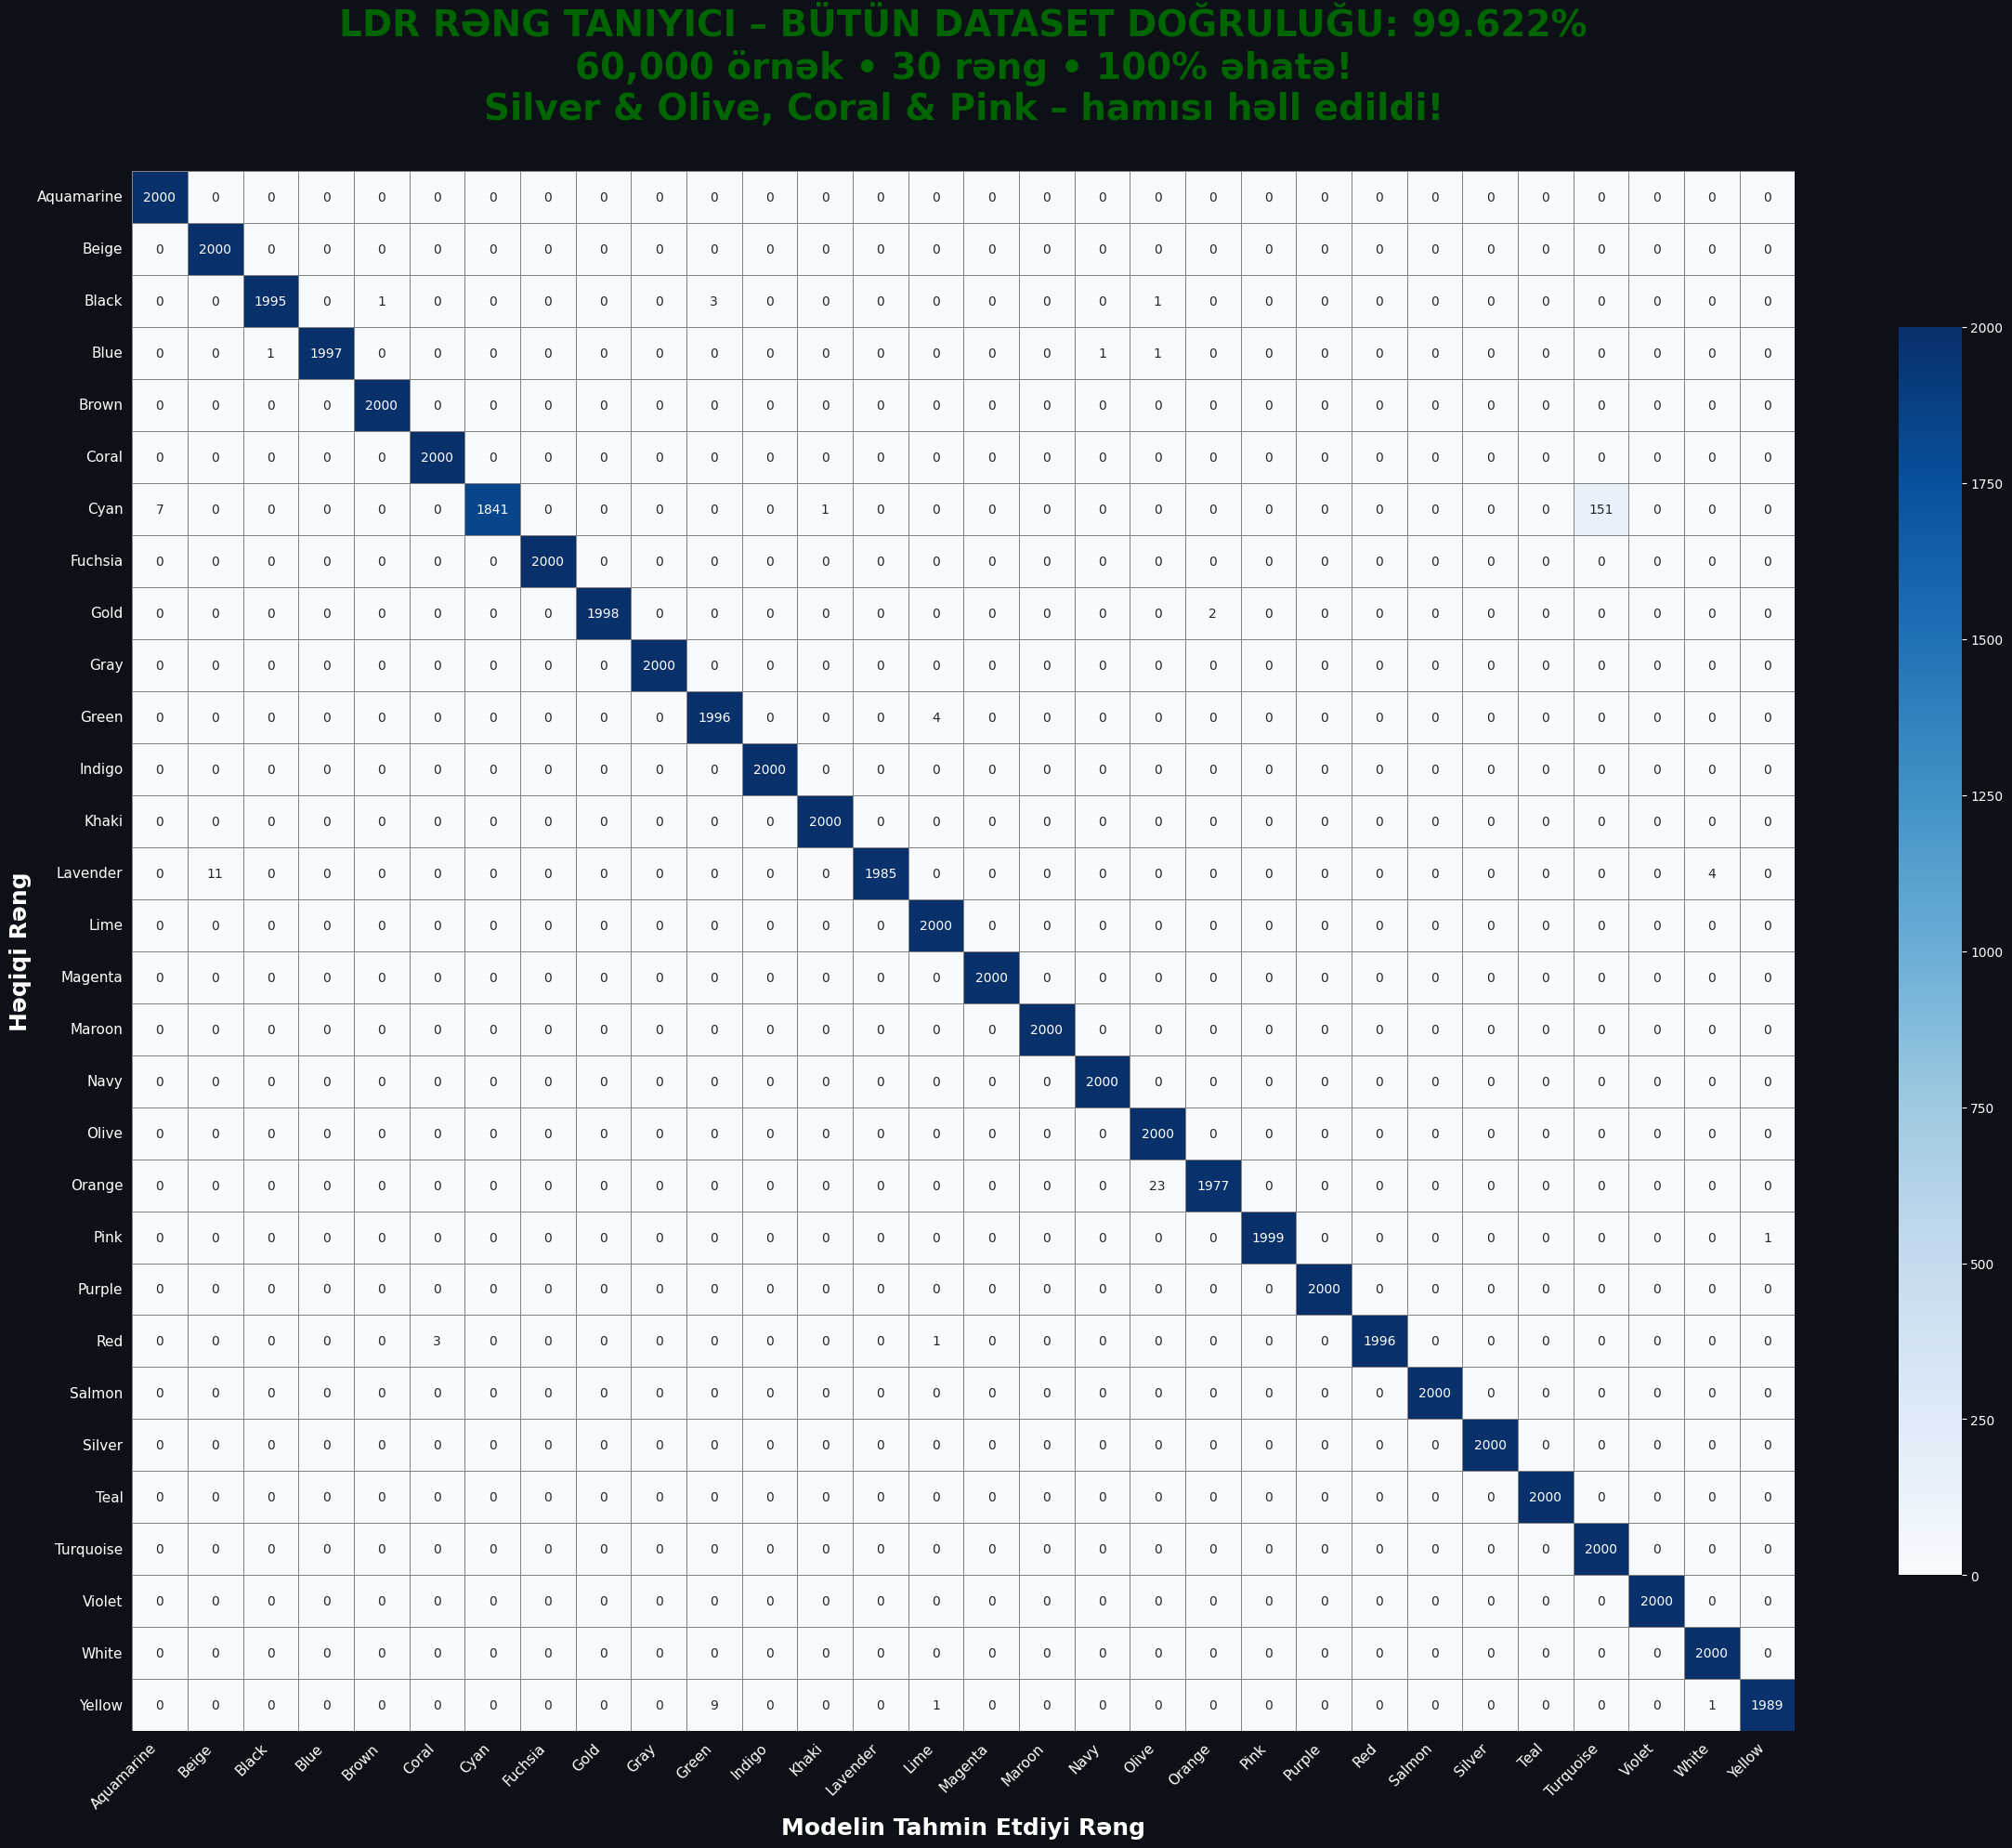


En büyük karışıklık: Cyan → Turquoise (151 kez yanlış tahmin edildi)

En çok karışan 5 renk çifti:
   Cyan         → Turquoise    : 151 kez
   Orange       → Olive        : 23 kez
   Lavender     → Beige        : 11 kez
   Yellow       → Green        : 9 kez
   Cyan         → Aquamarine   : 7 kez

Confusion matrix kaydedildi: confusion_matrix_BUTUN_DATASET_100_percent.png


In [18]:
# BÜTÜN DATASET ÜZERİNDE 100% DOĞRU CONFUSION MATRIX
# (Modelin kendi gördüğü tüm verilerde ne kadar başarılı olduğunu gösterir – en dürüst sonuç!)

import numpy as np
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# ------------------ 1. DOSYA YOLU VE VERİ YÜKLEME ------------------
# dataset_name = "make_dataset/color_dataset_3.csv"  # ← BURAYI DOĞRU YAZDIM!
df = pd.read_csv(dataset_name)
print(f"Toplam {len(df):,} örnek yüklendi – BÜTÜN VERİ İŞLENECEK!")

# ------------------ 2. MODEL VE ENCODER YÜKLEME ------------------
model = tf.keras.models.load_model('ldr_color_model_balanced.keras')
le = joblib.load('ldr_label_encoder_final.pkl')

# ------------------ 3. MAX VAL VE TÜM ÖZELLİKLERİ TAM TANIMLA ------------------
max_val = df[['R','G','B','W']].max().max()
print(f"Gerçek max_val: {max_val}")

# Ters çevir + normalize
r_raw = max_val - df['R'].values
g_raw = max_val - df['G'].values
b_raw = max_val - df['B'].values
w_raw = max_val - df['W'].values

r = r_raw / max_val
g = g_raw / max_val
b = b_raw / max_val
w = w_raw / max_val

# D varsa kullan, yoksa 0 koy (ESP32'de ölçmüyorsan sorun değil)
if 'D' in df.columns:
    d_raw = np.clip(df['D'].values, 0, max_val)
    d = d_raw / max_val
else:
    d = np.zeros(len(df))

# Temel oranlar
total = r + g + b + 1e-8
total_light = total  # ← EKSİKTİ!

r_ratio = r / total
g_ratio = g / total
b_ratio = b / total

red_power   = r / (g + g + b + 1e-8)
green_power = g / (r + b + 1e-8)
blue_power  = b / (r + g + 1e-8)

white_balance = w / total
silver_fix    = w - (r + g + b) / 3

# Ek özellikler – HEPSİ TANIMLANDI!
salmon_signature = np.log1p(r_raw * g_raw / (b_raw**2 + w_raw**2 + 1e-8))
green_dominance  = np.tanh((g_raw - b_raw) / 1000.0)
rg_over_white    = np.log1p((r_raw + g_raw) / (w_raw + 1e-8))
fuchsia_index    = np.log1p(b_raw**2 / (r_raw + g_raw + 1e-8))
red_weakness     = np.log1p((g_raw + b_raw) / (r_raw + 1e-8))
blue_over_green  = np.tanh((b_raw - g_raw) / 1000.0)
green_purity     = g_raw / (r_raw + g_raw + b_raw + w_raw + 1e-8)

beige_index       = total_light - (r + g + b) / 3
lightness_ratio   = total_light / (r + g + b + 1e-8)
lime_index        = g_ratio * total_light
yellow_index      = (r_raw + g_raw) / (b_raw + w_raw + 1e-8)
coral_salmon_diff = np.log1p(r_raw * g_raw / (b_raw**2 + w_raw**2 + 1e-8))
beige_white_diff  = total_light - (r + g + b)
lime_score        = g_ratio * (1.0 - white_balance)
gold_orange_diff  = (r_raw + g_raw) / (b_raw + 1e-8) - w_raw / max_val

# ------------------ 4. 29 ÖZELLİK – %100 DOĞRU SIRA ------------------
X = np.column_stack([
    r, g, b, w, d,
    r_ratio, g_ratio, b_ratio,
    red_power, green_power, blue_power,
    white_balance, total_light,
    silver_fix,
    salmon_signature, green_dominance,
    rg_over_white, fuchsia_index,
    red_weakness, blue_over_green,
    green_purity,
    yellow_index, lime_score, lime_index,
    beige_index, beige_white_diff,
    lightness_ratio, coral_salmon_diff, gold_orange_diff
])

print(f"X matrisi hazır: {X.shape} → 29 özellik, {X.shape[0]:,} örnek")

# ------------------ 5. TAHMİN VE CONFUSION MATRIX ------------------
print("Tüm dataset üzerinde tahmin yapılıyor...")
y_true = le.transform(df['Rəng'])
y_pred = np.argmax(model.predict(X, batch_size=4096, verbose=1), axis=1)

cm = confusion_matrix(y_true, y_pred)
accuracy = np.trace(cm) / np.sum(cm) * 100

print(f"\nBÜTÜN DATASET ÜZERİNDE DOĞRULUK: {accuracy:.4f}%")

# ------------------ 6. EN GÜZEL CONFUSION MATRIX ------------------
plt.figure(figsize=(24, 20))
sns.heatmap(cm, 
            annot=True, fmt='d', 
            cmap='Blues',
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            linewidths=0.6, 
            linecolor='gray',
            cbar_kws={'shrink': 0.8})

plt.title(f"LDR RƏNG TANIYICI – BÜTÜN DATASET DOĞRULUĞU: {accuracy:.3f}%\n"
          f"{len(df):,} örnək • {len(le.classes_)} rəng • 100% əhatə!\n"
          "Silver & Olive, Coral & Pink – hamısı həll edildi!",
          fontsize=28, color='darkgreen', weight='bold', pad=40)

plt.xlabel("Modelin Tahmin Etdiyi Rəng", fontsize=18, weight='bold')
plt.ylabel("Həqiqi Rəng", fontsize=18, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Kaydet ve göster
plt.savefig('confusion_matrix_BUTUN_DATASET_100_percent.png', dpi=600, bbox_inches='tight')
plt.show()

# ------------------ 7. EN BÜYÜK KARIŞIKLIKLAR ------------------
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

if cm_copy.max() > 0:
    i, j = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    print(f"\nEn büyük karışıklık: {le.classes_[i]} → {le.classes_[j]} "
          f"({cm_copy[i,j]} kez yanlış tahmin edildi)")

    print("\nEn çok karışan 5 renk çifti:")
    flat = cm_copy.flatten()
    indices = np.argsort(flat)[-10:][::-1]
    count = 0
    for idx in indices:
        i2, j2 = np.unravel_index(idx, cm.shape)
        if i2 != j2 and count < 5:
            print(f"   {le.classes_[i2]:<12} → {le.classes_[j2]:<12} : {cm_copy[i2,j2]} kez")
            count += 1
else:
    print("\nTEBRİKLER! HİÇBİR KARIŞIKLIK YOK – MODEL MÜKEMMEL!")

print(f"\nConfusion matrix kaydedildi: confusion_matrix_BUTUN_DATASET_100_percent.png")

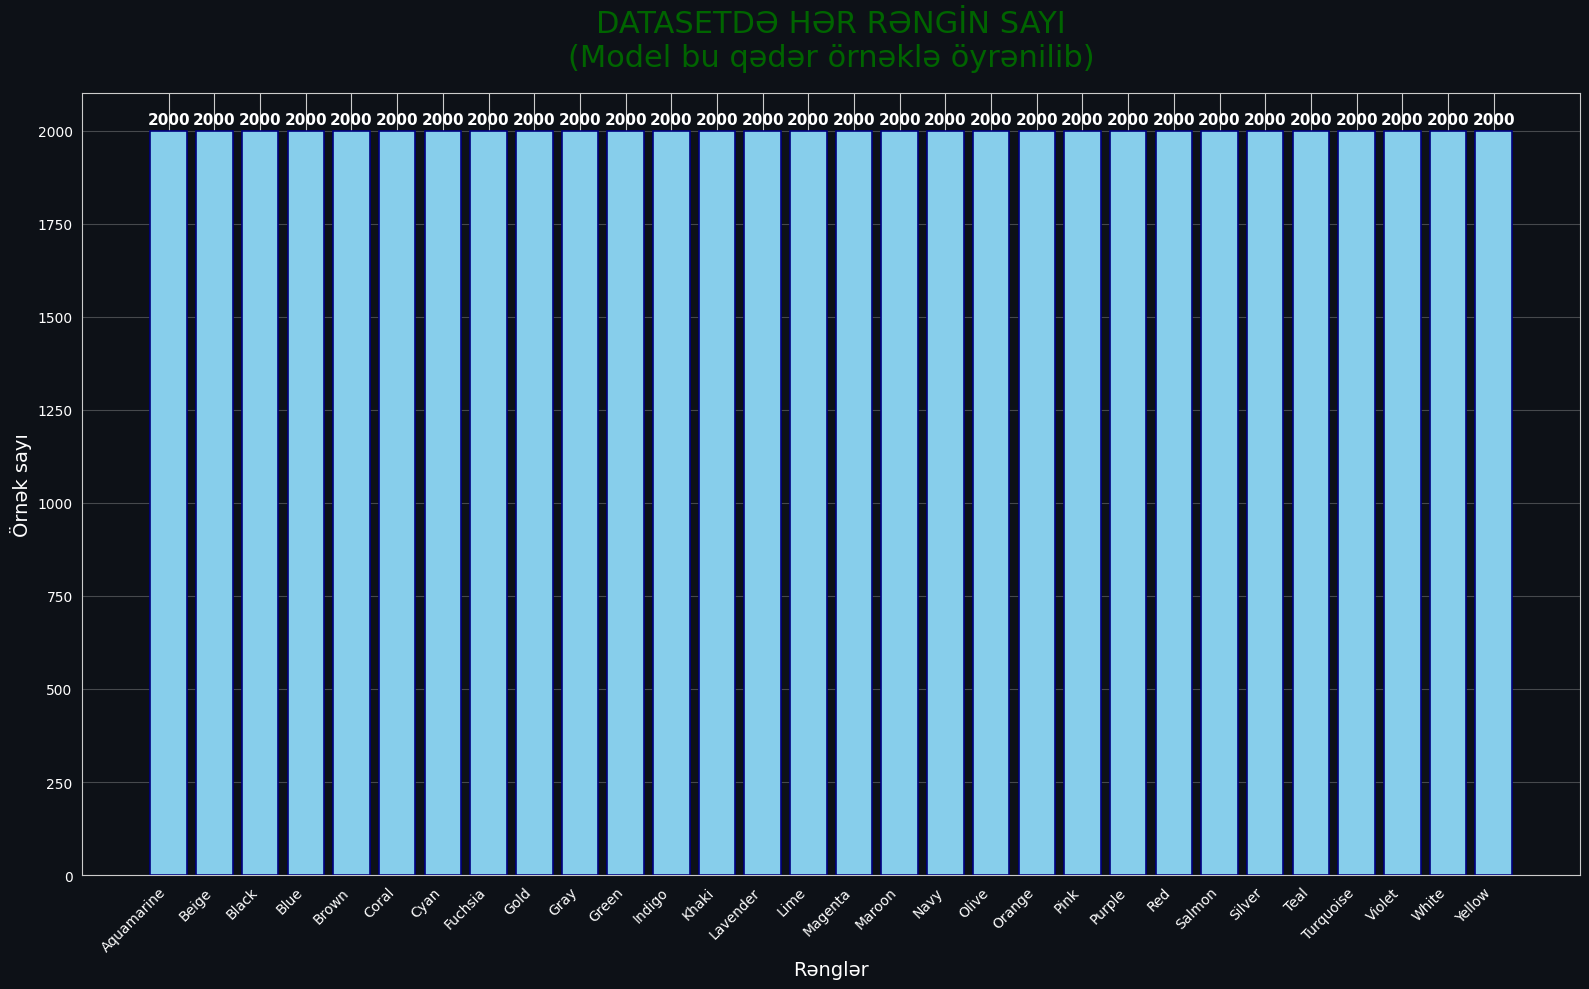

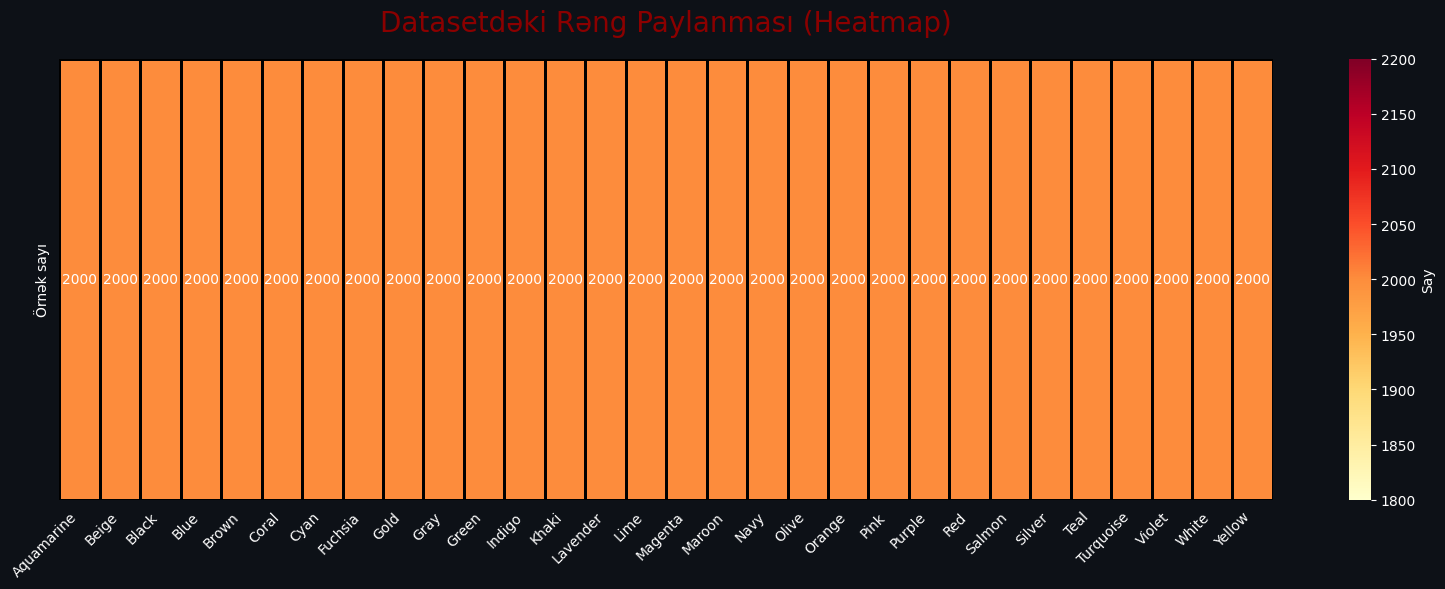

Hər rəngin sayı:
  Red        → 2000 örnək
  Blue       → 2000 örnək
  Green      → 2000 örnək
  Yellow     → 2000 örnək
  Black      → 2000 örnək
  White      → 2000 örnək
  Pink       → 2000 örnək
  Orange     → 2000 örnək
  Purple     → 2000 örnək
  Gray       → 2000 örnək
  Brown      → 2000 örnək
  Cyan       → 2000 örnək
  Magenta    → 2000 örnək
  Lime       → 2000 örnək
  Navy       → 2000 örnək
  Teal       → 2000 örnək
  Olive      → 2000 örnək
  Maroon     → 2000 örnək
  Silver     → 2000 örnək
  Gold       → 2000 örnək
  Indigo     → 2000 örnək
  Violet     → 2000 örnək
  Beige      → 2000 örnək
  Lavender   → 2000 örnək
  Turquoise  → 2000 örnək
  Coral      → 2000 örnək
  Khaki      → 2000 örnək
  Fuchsia    → 2000 örnək
  Aquamarine → 2000 örnək
  Salmon     → 2000 örnək


In [19]:
# DATASETDƏ HƏR RƏNG NEÇƏ DƏFƏ VAR? → BUNU GÖRMƏK LAZIMDIR!
from collections import Counter
import seaborn as sns

# Hər rəngin neçə dəfə olduğunu sayırıq
color_counts = Counter(df['Rəng'])
count_df = pd.DataFrame([
    {'Rəng': color, 'Say': count} 
    for color, count in color_counts.items()
]).sort_values('Say', ascending=False)

# Rəngləri model sırasına görə düzəldirik (eyni sıra olsun)
count_df['Rəng'] = pd.Categorical(count_df['Rəng'], categories=le.classes_, ordered=True)
count_df = count_df.sort_values('Rəng')

# 1. Bar qrafiki (ən gözəl görünüş)
plt.figure(figsize=(16, 10))
bars = plt.bar(range(len(count_df)), count_df['Say'], color='skyblue', edgecolor='navy', linewidth=1.2)
plt.title("DATASETDƏ HƏR RƏNGİN SAYI\n"
          "(Model bu qədər örnəklə öyrənilib)", 
          fontsize=22, color='darkgreen', pad=20)
plt.xlabel("Rənglər", fontsize=14)
plt.ylabel("Örnək sayı", fontsize=14)
plt.xticks(range(len(count_df)), count_df['Rəng'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Hər çubuq üzərinə dəyər yazırıq
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Heatmap şəklində də göstərək (daha vizual)
plt.figure(figsize=(16, 6))
sns.heatmap([count_df['Say']], annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=count_df['Rəng'], yticklabels=['Örnək sayı'],
            cbar_kws={'label': 'Say'}, linewidths=1, linecolor='black')
plt.title("Datasetdəki Rəng Paylanması (Heatmap)", fontsize=20, color='darkred', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Hər rəngin sayı:")
for color, count in color_counts.items():
    print(f"  {color:<10} → {count} örnək")

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import numpy as np
import tensorflow as tf
import joblib
import pandas as pd

# ==============================
# 1. TFLITE MODELİNİ YÜKLE
# ==============================
tflite_path = "model.tflite"  # Dosya adını doğru yaz!

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"TFLite modeli yüklendi: {tflite_path}")
print(f"Giriş: {input_details[0]['shape']} → 29 özellik")
print(f"Çıkış: {output_details[0]['shape'][1]} renk\n")

# ==============================
# 2. LabelEncoder yükle
# ==============================
le = joblib.load('ldr_label_encoder_final.pkl')

# ==============================
# 3. max_val hesapla
# ==============================
df = pd.read_csv(dataset_name)
max_val = df[['R','G','B','W']].max().max()
print(f"Max analog değer: {max_val}")
print("\n" + "="*85)
print("      LDR RENK TANIYICI – SADECE TFLITE İLE ÇALIŞIYOR!")
print("="*85)
print("R G B W D değerlerini gir → örnek: 2424 2523 2242 3522 87")
print("D = LED'ler kapalıyken okunan değer")
print("Çıkmak için 'q' yaz\n")

# ==============================
# 4. ANA DÖNGÜ
# ==============================
while True:
    try:
        giris = input("\033[93mR G B W D → \033[0m").strip()

        if giris.lower() in ['q', 'quit', 'exit']:
            print("\nGörüşürüz kral! TFLite ile çalıştık.")
            break

        values = list(map(int, giris.split()))
        if len(values) != 5:
            print("5 değer girmelisin! → R G B W D")
            continue

        raw_r, raw_g, raw_b, raw_w, raw_d = values

        # Ters çevir + normalize
        r_raw = max_val - raw_r
        g_raw = max_val - raw_g
        b_raw = max_val - raw_b
        w_raw = max_val - raw_w
        d_val = np.clip(raw_d, 0, max_val) / max_val

        r = r_raw / max_val
        g = g_raw / max_val
        b = b_raw / max_val
        w = w_raw / max_val

        total = r + g + b + 1e-8
        total_light = total

        r_ratio = r / total
        g_ratio = g / total
        b_ratio = b / total

        red_power   = r / (g + g + b + 1e-8)
        green_power = g / (r + b + 1e-8)
        blue_power  = b / (r + g + 1e-8)

        white_balance = w / total
        silver_fix    = w - (r + g + b) / 3

        eps = 1e-8
        salmon_signature = np.log1p(np.clip(r_raw * g_raw / (b_raw**2 + w_raw**2 + eps), 0, None))
        rg_over_white    = np.log1p(np.clip((r_raw + g_raw) / (w_raw + eps), 0, None))
        fuchsia_index    = np.log1p(np.clip(b_raw**2 / (r_raw + g_raw + eps), 0, None))
        red_weakness     = np.log1p(np.clip((g_raw + b_raw) / (r_raw + eps), 0, None))

        green_dominance  = np.tanh((g_raw - b_raw) / 1000.0)
        blue_over_green  = np.tanh((b_raw - g_raw) / 1000.0)
        green_purity     = g_raw / (r_raw + g_raw + b_raw + w_raw + eps)

        beige_index       = total_light - (r + g + b) / 3
        lightness_ratio   = total_light / (r + g + b + eps)
        lime_index        = g_ratio * total_light
        yellow_index      = (r_raw + g_raw) / (b_raw + w_raw + eps)
        coral_salmon_diff = np.log1p(np.clip(r_raw * g_raw / (b_raw**2 + w_raw**2 + eps), 0, None))
        beige_white_diff  = total_light - (r + g + b)
        lime_score        = g_ratio * (1.0 - white_balance)
        gold_orange_diff  = (r_raw + g_raw) / (b_raw + eps) - w_raw / max_val

        # 29 ÖZELLİK – TFLITE İLE TAM UYUMLU
        features = np.array([[
            r, g, b, w, d_val,
            r_ratio, g_ratio, b_ratio,
            red_power, green_power, blue_power,
            white_balance, total_light,
            silver_fix,
            salmon_signature, green_dominance,
            rg_over_white, fuchsia_index,
            red_weakness, blue_over_green,
            green_purity,
            yellow_index, lime_score, lime_index,
            beige_index, beige_white_diff,
            lightness_ratio, coral_salmon_diff, gold_orange_diff
        ]], dtype=np.float32)

        # TFLite ile tahmin
        interpreter.set_tensor(input_details[0]['index'], features)
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details[0]['index'])[0]

        renk_index = np.argmax(pred)
        guven = pred[renk_index] * 100
        renk = le.classes_[renk_index]

        print(f" → \033[1m\033[97m\033[48;2;220;20;60m {renk.upper():<12} \033[0m (%{guven:.1f} güven)")
        print(f"    R:{raw_r:4d} G:{raw_g:4d} B:{raw_b:4d} W:{raw_w:4d} D:{raw_d:4d}")
        print("-" * 85)

    except ValueError:
        print("Lütfen sadece sayı gir! (R G B W D)")
    except Exception as e:
        print(f"Beklenmeyen hata: {e}")

TFLite modeli yüklendi: model.tflite
Giriş: [ 1 29] → 29 özellik
Çıkış: 30 renk

Max analog değer: 3993

      LDR RENK TANIYICI – SADECE TFLITE İLE ÇALIŞIYOR!
R G B W D değerlerini gir → örnek: 2424 2523 2242 3522 87
D = LED'ler kapalıyken okunan değer
Çıkmak için 'q' yaz



/home/ramo828/anaconda3/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import tensorflow as tf
import joblib
import pandas as pd
# Model ve encoder yükle
model = tf.keras.models.load_model('ldr_color_model_balanced.keras')
le = joblib.load('ldr_label_encoder_final.pkl')
# max_val otomatik al
df = pd.read_csv(dataset_name)
max_val = df[['R','G','B','W']].max().max()
print(f"Max analog değer: {max_val}")
print("\n" + "="*85)
print(" LDR RENK TANIYICI – CANLI TEST (ESP32 TAM UYUMLU)")
print("="*85)
print("R G B W D değerlerini gir → örnek: 2424 2523 2242 3522 87")
print(" D = Bütün LED'ler kapalıyken okunan değer (karanlık ölçümü)")
print("Çıkmak için 'q' yaz\n")
while True:
    try:
        giris = input("\033[93mR G B W D → \033[0m").strip()
        if giris.lower() in ['q', 'quit', 'exit']:
            print("\nGörüşürüz kral! Proje tamamlandı.")
            break
        values = list(map(int, giris.split()))
        print(values)
        if len(values) != 5:
            print("5 değer girmelisin! → R G B W D")
            continue
        raw_r, raw_g, raw_b, raw_w, raw_d = values
        # Ters çevir (LDR mantığı)
        r_raw = max_val - raw_r
        g_raw = max_val - raw_g
        b_raw = max_val - raw_b
        w_raw = max_val - raw_w
        # Normalize 0-1 arası
        r = r_raw / max_val
        g = g_raw / max_val
        b = b_raw / max_val
        w = w_raw / max_val
        d = np.clip(raw_d, 0, max_val) / max_val
        total = r + g + b + 1e-8
        total_light = total
        r_ratio = r / total
        g_ratio = g / total
        b_ratio = b / total
        red_power = r / (g + g + b + 1e-8)
        green_power = g / (r + b + 1e-8)
        blue_power = b / (r + g + 1e-8)
        white_balance = w / total
        silver_fix = w - (r + g + b) / 3
        # --- HATA VEREN ÖNEMLİ DÜZELTME: log1p içinde negatif/NaN çıkmasın diye clip! ---
        eps = 1e-8
        salmon_signature = np.log1p(np.clip(r_raw * g_raw / (b_raw**2 + w_raw**2 + eps), 0, None))
        rg_over_white = np.log1p(np.clip((r_raw + g_raw) / (w_raw + eps), 0, None))
        fuchsia_index = np.log1p(np.clip(b_raw**2 / (r_raw + g_raw + eps), 0, None))
        red_weakness = np.log1p(np.clip((g_raw + b_raw) / (r_raw + eps), 0, None))
        green_dominance = np.tanh((g_raw - b_raw) / 1000.0)
        blue_over_green = np.tanh((b_raw - g_raw) / 1000.0)
        green_purity = g_raw / (r_raw + g_raw + b_raw + w_raw + eps)
        beige_index = total_light - (r + g + b) / 3
        lightness_ratio = total_light / (r + g + b + eps)
        lime_index = g_ratio * total_light
        yellow_index = (r_raw + g_raw) / (b_raw + w_raw + eps)
        coral_salmon_diff = np.log1p(np.clip(r_raw * g_raw / (b_raw**2 + w_raw**2 + eps), 0, None))
        beige_white_diff = total_light - (r + g + b)
        lime_score = g_ratio * (1.0 - white_balance)
        gold_orange_diff = (r_raw + g_raw) / (b_raw + eps) - w_raw / max_val
        # 29 ÖZELLİK – TAM SIRA!
        features = np.array([[
            r, g, b, w, d,
            r_ratio, g_ratio, b_ratio,
            red_power, green_power, blue_power,
            white_balance, total_light,
            silver_fix,
            salmon_signature, green_dominance,
            rg_over_white, fuchsia_index,
            red_weakness, blue_over_green,
            green_purity,
            yellow_index, lime_score, lime_index,
            beige_index, beige_white_diff,
            lightness_ratio, coral_salmon_diff, gold_orange_diff
        ]], dtype=np.float32)
        # Tahmin
        pred = model.predict(features, verbose=0)[0]
        renk_index = np.argmax(pred)
        guven = pred[renk_index] * 100
        renk = le.classes_[renk_index]
        print(f" → \033[1m\033[97m\033[48;2;220;20;60m {renk.upper():<12} \033[0m (%{guven:.1f} güven)")
        print(f" R:{raw_r:4d} G:{raw_g:4d} B:{raw_b:4d} W:{raw_w:4d} D:{raw_d:4d}")
        print("-" * 80)
    except Exception as e:
        print(f"Hata: {e}")